# Towards Autonomous Cybersecurity: An Intelligent AutoML Framework for Autonomous Intrusion Detection 
This is the code for the paper entitled "[**Towards Autonomous Cybersecurity: An Intelligent AutoML Framework for Autonomous Intrusion Detection**](https://arxiv.org/pdf/2409.03141)" accepted in Workshop on Autonomous Cybersecurity (AutonomousCyber 2024), ACM CCS 2024 (Top Cybersecurity Conference).  
Authors: Li Yang (liyanghart@gmail.com) and Abdallah Shami  

If you find this repository useful in your research, please cite:  
L. Yang and A. Shami, “Towards Autonomous Cybersecurity: An Intelligent AutoML Framework for Autonomous Intrusion Detection,” in Proceedings of the Workshop on Autonomous Cybersecurity (AutonomousCyber ’24), 2024 ACM SIGSAC Conference on Computer and Communications Security (CCS’24), 2024, pp. 1–11. doi: 10.1145/3689933.3690833.

```
@INPROCEEDINGS{3690833,
  author={Yang, Li and Shami, Abdallah},
  title = {Towards Autonomous Cybersecurity: An Intelligent AutoML Framework for Autonomous Intrusion Detection},
  booktitle = {Proceedings of the Workshop on Autonomous Cybersecurity (AutonomousCyber '24), ACM Conference on Computer and Communications Security (CCS) 2024},
  year = {2024},
  address = {Salt Lake City, UT, USA},
  pages = {1-11},
  doi = {10.1145/3689933.3690833}
}
```

## Import libraries

In [ ]:
# Install required third-party packages if not available
!pip install catboost hyperopt sdv xgboost lightgbm

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_recall_fscore_support
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb
from xgboost import plot_importance
import lightgbm as lgb
import catboost as cb
import time

---

# Dataset 1: CICIDS2017

---

## Dataset 1: CICIDS2017
The CICIDS2017 dataset is publicly available at: https://www.unb.ca/cic/datasets/ids-2017.html  

Due to the large size of this dataset and the file size limit of GitHub, the sampled subset of CICIDS2017 is used. The subsets are in the "Data" folder.  PS: The results might be different from the paper due to the size difference of the dataset.

The Canadian Institute for Cybersecurity Intrusion Detection System 2017 (CICIDS2017) dataset has the most updated network threats. The CICIDS2017 dataset is close to real-world network data since it has a large amount of network traffic data, a variety of network features, various types of attacks, and highly imbalanced classes.


### Load data

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [28]:
# Read the dataset
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Assignment/Data/CICIDS2017_sample_0.02.csv')

In [29]:
# print the class distribution of the last column
df['Label'].value_counts()

Label
BENIGN          22731
DoS             19035
PortScan         7946
BruteForce       2767
WebAttack        2180
Bot              1966
Infiltration       36
Name: count, dtype: int64

### Data pre-processing

In [30]:
# Encode the dataset (Label & all string/categorical feature columns)
from sklearn.preprocessing import LabelEncoder

# Automatically detect and encode all string/object/categorical columns
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

labelencoder = LabelEncoder()
if 'Label' in df.columns:
    df['Label'] = labelencoder.fit_transform(df['Label'])
else:
    df.iloc[:, -1] = labelencoder.fit_transform(df.iloc[:, -1])

# Address empty or infinite values if present
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

X = df.drop(['Label'], axis=1).values.astype(np.float64)
y = df['Label'].values if 'Label' in df.columns else df.iloc[:, -1].values
y = np.ravel(y)


In [31]:
# address empty values
if df.isnull().values.any() or np.isinf(df).values.any(): # if there is any empty or infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace = True) 

In [32]:
# Split the dataset into training and testing
X = df.drop(['Label'],axis=1).values.astype(np.float64) 
y = df.iloc[:, -1].values.reshape(-1,1)
y=np.ravel(y)
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

## Machine learning model training

### Training six base learners (for comparison purposes): 
decision tree, random forest, extra trees, XGBoost, LightGBM, and CatBoost


### Cross-validation

#### DT

Training time:  1.4612987041473389
Prediction time per sample:  0.00044006351695460025
Cross-Validation scores:  [0.99490404 0.99291813 0.9935138 ]
Mean of Cross-Validation scores:  0.9937786550171627
Accuracy of DT: 0.9955881055325156
Precision of DT: 0.9955619442695871
Recall of DT: 0.9955881055325156
F1-score of DT: 0.9955567987296642
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4547
           1       0.99      0.98      0.98       393
           2       0.99      1.00      0.99       554
           3       1.00      1.00      1.00      3807
           4       0.80      0.57      0.67         7
           5       1.00      1.00      1.00      1589
           6       0.99      1.00      0.99       436

    accuracy                           1.00     11333
   macro avg       0.96      0.93      0.95     11333
weighted avg       1.00      1.00      1.00     11333



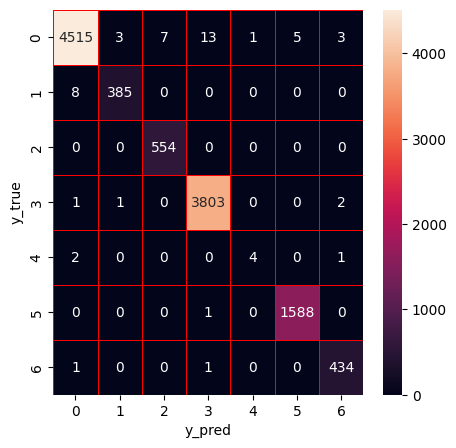

CPU times: total: 4.33 s
Wall time: 5 s


In [33]:
%%time
X_train = np.asarray(X_train, dtype=np.float64)
y_train = np.asarray(y_train)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
# Decision tree training and prediction with 3-fold cross-validation
dt = DecisionTreeClassifier(random_state=0)
dt_scores = cross_val_score(dt, X_train, y_train, cv=3)
# calculate the training time
start = time.time()
dt.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = dt.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test)*1000)
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', dt_scores)
print('Mean of Cross-Validation scores: ', np.mean(dt_scores))
# Evaluation metrics
dt_score = dt.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of DT: ' + str(dt_score))
print('Precision of DT: ' + str(precision))
print('Recall of DT: ' + str(recall))
print('F1-score of DT: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### RF

Training time:  16.45930314064026
Prediction time:  0.033181731660715495 ms
Cross-Validation scores:  [0.99364659 0.99371236 0.99404329]
Mean of Cross-Validation scores:  0.9938007446645121
Accuracy of RF: 0.9951469160857672
Precision of RF: 0.9951376956404765
Recall of RF: 0.9951469160857672
F1-score of RF: 0.9951233485431371
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4547
           1       0.98      0.97      0.98       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       0.99      0.97      0.98       436

    accuracy                           1.00     11333
   macro avg       0.99      0.95      0.97     11333
weighted avg       1.00      1.00      1.00     11333



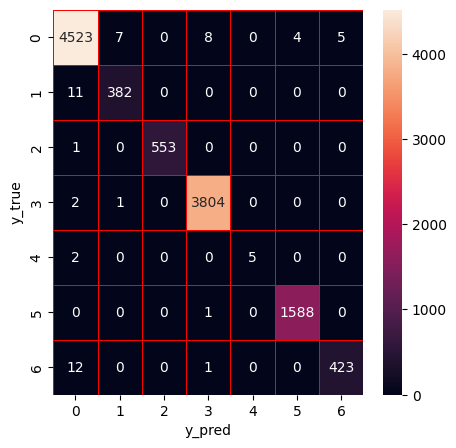

CPU times: total: 36.6 s
Wall time: 44.8 s


In [34]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Random Forest training and prediction with 3-fold cross-validation
rf = RandomForestClassifier(random_state=0)
rf_scores = cross_val_score(rf, X_train, y_train, cv=3)
# calculate the training time
start = time.time()
rf.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = rf.predict(X_test)
end = time.time()
print('Prediction time: ', (end - start) / len(y_predict) * 1000, 'ms')
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', rf_scores)
print('Mean of Cross-Validation scores: ', np.mean(rf_scores))
# Evaluation metrics
rf_score = rf.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of RF: ' + str(rf_score))
print('Precision of RF: ' + str(precision))
print('Recall of RF: ' + str(recall))
print('F1-score of RF: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### ET

Training time:  9.446037530899048
Prediction time:  0.029573097218905883 ms
Cross-Validation scores:  [0.98808736 0.98768946 0.98828513]
Mean of Cross-Validation scores:  0.9880206480164281
Accuracy of ET: 0.9894996911673872
Precision of ET: 0.9895868550132068
Recall of ET: 0.9894996911673872
F1-score of ET: 0.9894399241016295
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      4547
           1       0.93      0.97      0.95       393
           2       0.98      1.00      0.99       554
           3       0.99      1.00      1.00      3807
           4       1.00      0.43      0.60         7
           5       1.00      1.00      1.00      1589
           6       0.98      0.96      0.97       436

    accuracy                           0.99     11333
   macro avg       0.98      0.91      0.93     11333
weighted avg       0.99      0.99      0.99     11333



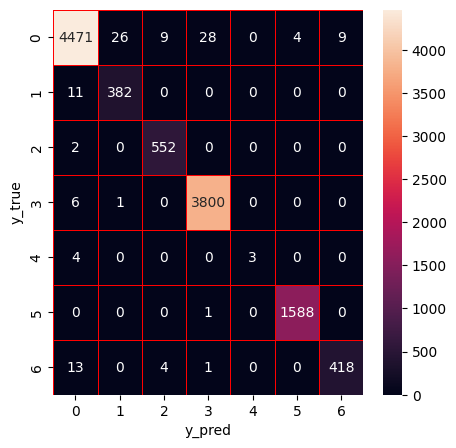

CPU times: total: 23.6 s
Wall time: 28.8 s


In [35]:
%%time
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Extra Trees training and prediction with 3-fold cross-validation
et = ExtraTreesClassifier(random_state=0)
et_scores = cross_val_score(et, X_train, y_train, cv=3)
# calculate the training time
start = time.time()
et.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = et.predict(X_test)
end = time.time()
print('Prediction time: ', (end - start) / len(X_test) * 1000, 'ms')
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', et_scores)
print('Mean of Cross-Validation scores: ', np.mean(et_scores))
# Evaluation metrics
et_score = et.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of ET: ' + str(et_score))
print('Precision of ET: ' + str(precision))
print('Recall of ET: ' + str(recall))
print('F1-score of ET: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### XGBoost

Training time:  35.850178480148315
Prediction time per sample:  0.002904339269201995
Cross-Validation scores:  [0.9971542  0.99728639 0.99695546]
Mean of Cross-Validation scores:  0.9971320150417519
Accuracy of XGBoost: 0.9981470043236566
Precision of XGBoost: 0.9981468800890866
Recall of XGBoost: 0.9981470043236566
F1-score of XGBoost: 0.9981299358057846
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       1.00      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



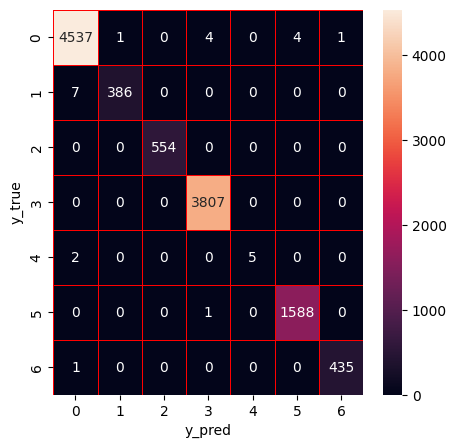

In [36]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# XGBoost training and prediction with 3-fold cross-validation
xg = xgb.XGBClassifier(random_state=0)
xg_scores = cross_val_score(xg, X_train, y_train, cv=3)

# calculate the training time
start = time.time()
xg.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = xg.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)


y_true = y_test

# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', xg_scores)
print('Mean of Cross-Validation scores: ', np.mean(xg_scores))

# Evaluation metrics
xg_score = xg.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of XGBoost: ' + str(xg_score))
print('Precision of XGBoost: ' + str(precision))
print('Recall of XGBoost: ' + str(recall))
print('F1-score of XGBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### LightGBM

Training time:  6.52846097946167
Prediction time per sample:  0.008625459515342621
Cross-Validation scores:  [0.99722038 0.50095969 0.99662453]
Mean of Cross-Validation scores:  0.8316015350589306
Accuracy of LightGBM: 0.7114621018265244
Precision of LightGBM: 0.730995389977396
Recall of LightGBM: 0.7114621018265244
F1-score of LightGBM: 0.7091902373464247
              precision    recall  f1-score   support

           0       0.89      0.68      0.77      4547
           1       0.30      0.67      0.42       393
           2       0.00      0.00      0.00       554
           3       0.69      0.83      0.76      3807
           4       0.00      0.00      0.00         7
           5       0.82      0.92      0.87      1589
           6       0.45      0.22      0.29       436

    accuracy                           0.71     11333
   macro avg       0.45      0.47      0.44     11333
weighted avg       0.73      0.71      0.71     11333



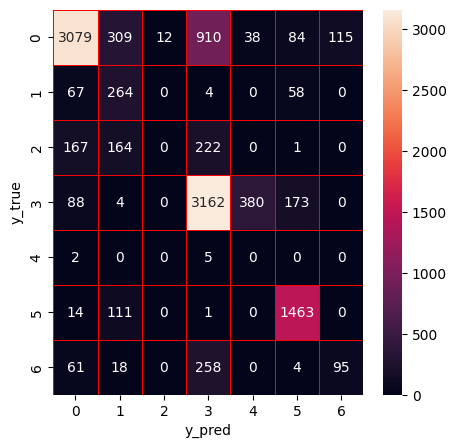

In [37]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# LightGBM training and prediction with 3-fold cross-validation
lgbm = lgb.LGBMClassifier(random_state=0)
lgbm_scores = cross_val_score(lgbm, X_train, y_train, cv=3)

# calculate the training time
start = time.time()
lgbm.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = lgbm.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)



y_true = y_test

# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', lgbm_scores)
print('Mean of Cross-Validation scores: ', np.mean(lgbm_scores))

# Evaluation metrics
lgbm_score = lgbm.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of LightGBM: ' + str(lgbm_score))
print('Precision of LightGBM: ' + str(precision))
print('Recall of LightGBM: ' + str(recall))
print('F1-score of LightGBM: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### Catboost

Training time:  84.00885319709778
Prediction time per sample:  0.0303641512567932
Cross-Validation scores:  [0.99662475 0.99688927 0.99695546]
Mean of Cross-Validation scores:  0.9968231600425393
Accuracy of CatBoost: 0.9972646254301597
Precision of CatBoost: 0.9972667325353783
Recall of CatBoost: 0.9972646254301597
F1-score of CatBoost: 0.9972288336160174
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.98      0.99      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.57      0.73         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.94      0.96     11333
weighted avg       1.00      1.00      1.00     11333



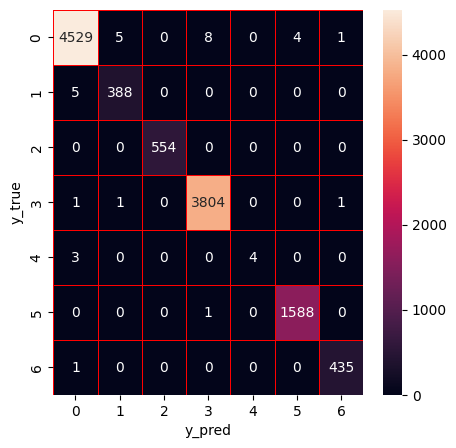

In [38]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# CatBoost training and prediction with 3-fold cross-validation
cat = CatBoostClassifier(random_state=0, verbose=False)
cat_scores = cross_val_score(cat, X_train, y_train, cv=3)


# calculate the training time
start = time.time()
cat.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = cat.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)


# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', cat_scores)
print('Mean of Cross-Validation scores: ', np.mean(cat_scores))

# Evaluation metrics
cat_score = cat.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of CatBoost: ' + str(cat_score))
print('Precision of CatBoost: ' + str(precision))
print('Recall of CatBoost: ' + str(recall))
print('F1-score of CatBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


In [39]:
# record the results
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)
dt_prob_train=dt.predict_proba(X_train)
dt_prob_test=dt.predict_proba(X_test)

rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)
rf_prob_train=rf.predict_proba(X_train)
rf_prob_test=rf.predict_proba(X_test)

et_train=et.predict(X_train)
et_test=et.predict(X_test)
et_prob_train=et.predict_proba(X_train)
et_prob_test=et.predict_proba(X_test)

xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)
xg_prob_train=xg.predict_proba(X_train)
xg_prob_test=xg.predict_proba(X_test)

lgbm_train=lgbm.predict(X_train)
lgbm_test=lgbm.predict(X_test)
lgbm_prob_train=lgbm.predict_proba(X_train)
lgbm_prob_test=lgbm.predict_proba(X_test)

cat_train=cat.predict(X_train)
cat_test=cat.predict(X_test)
cat_prob_train=cat.predict_proba(X_train)
cat_prob_test=cat.predict_proba(X_test)


# Save Phase 1 Base Models
import os, joblib
model_dir = '/content/drive/My Drive/Colab Notebooks/Assignment/Data/models_dataset1/'
os.makedirs(model_dir + 'phase1_initial_base_models', exist_ok=True)
joblib.dump(dt, model_dir + 'phase1_initial_base_models/dt_model.joblib')
joblib.dump(rf, model_dir + 'phase1_initial_base_models/rf_model.joblib')
joblib.dump(et, model_dir + 'phase1_initial_base_models/et_model.joblib')
joblib.dump(xg, model_dir + 'phase1_initial_base_models/xg_model.joblib')
joblib.dump(lgbm, model_dir + 'phase1_initial_base_models/lgbm_model.joblib')
joblib.dump(cat, model_dir + 'phase1_initial_base_models/cat_model.joblib')
print('Phase 1: Initial Base Models saved successfully to Google Drive!')

## Model selection

In [40]:
# Calculate the performance of each base model (e.g., accuracy)
base_model_performance = {
    'dt': np.mean(dt_scores),
    'rf': np.mean(rf_scores),
    'et': np.mean(et_scores),
    'xg': np.mean(xg_scores),
    'lgbm': np.mean(lgbm_scores),
    'cat': np.mean(cat_scores)

}

# Rank the base models based on their performance
ranked_models = sorted(base_model_performance, key=base_model_performance.get, reverse=True)

# Select the top-3 performing base models
top_3_models = ranked_models[:3]



In [41]:
top_3_models

['xg', 'cat', 'rf']

## Model Ensemble

In [42]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
lgbm_train=lgbm_train.reshape(-1, 1)
cat_train=cat_train.reshape(-1, 1)


dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)
lgbm_test=lgbm_test.reshape(-1, 1)
cat_test=cat_test.reshape(-1, 1)

Training time of Stacking: 3.4441423416137695
Testing time of Stacking: 0.0005281267104708043
Accuracy of Stacking: 0.9981470043236566
Precision of Stacking: 0.9981468800890866
Recall of Stacking: 0.9981470043236566
F1-score of Stacking: 0.9981299358057846
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       1.00      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



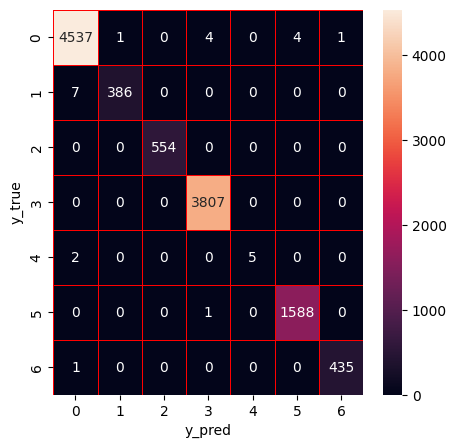

In [43]:
# Ensemble method 1: traditional stacking

# Get the predictions of the top-3 models
top_3_train_predictions = [globals()[model.lower() + '_train'] for model in top_3_models]
top_3_test_predictions = [globals()[model.lower() + '_test'] for model in top_3_models]

# Stack the predictions of the top-3 models
x_train = np.concatenate(top_3_train_predictions, axis=1)
x_test = np.concatenate(top_3_test_predictions, axis=1)

# Train and evaluate the stacking model
# calcualte the traning time
start_time = time.time()
#stk = lgb.LGBMClassifier().fit(x_train, y_train)
stk =  xgb.XGBClassifier(random_state=0).fit(x_train, y_train)
end_time = time.time()
stk_time = end_time - start_time
print('Training time of Stacking: '+ str(stk_time))

# calcualte the testing time per sample in milliseconds
start_time = time.time()
y_predict=stk.predict(x_test)
end_time = time.time()
stk_time = (end_time - start_time)/len(x_test)*1000
print('Testing time of Stacking: '+ str(stk_time))

y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


Training time of Stacking: 8.537046194076538
Testing time of Stacking: 0.0006160636786737983
Accuracy of Stacking: 0.9981470043236566
Precision of Stacking: 0.9981468800890866
Recall of Stacking: 0.9981470043236566
F1-score of Stacking: 0.9981299358057846
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       1.00      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



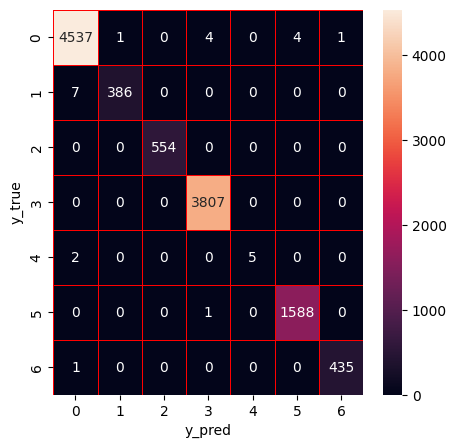

In [44]:
# Ensemble method 2: confidence-based stacking

# Get the prediction probabilities of the top-3 models
top_3_train_proba = [globals()[model.lower() + '_prob_train'] for model in top_3_models]
top_3_test_proba = [globals()[model.lower() + '_prob_test'] for model in top_3_models]

# Stack the predictions and prediction probabilities of the top-3 models
x_train = np.concatenate(top_3_train_proba, axis=1)
x_test = np.concatenate(top_3_test_proba, axis=1)

# Train and evaluate the stacking model
# calcualte the traning time
start_time = time.time()
#stk = lgb.LGBMClassifier().fit(x_train, y_train)
stk =  xgb.XGBClassifier(random_state=0).fit(x_train, y_train)
end_time = time.time()
stk_time = end_time - start_time
print('Training time of Stacking: '+ str(stk_time))

# calcualte the testing time per sample in milliseconds
start_time = time.time()
y_predict=stk.predict(x_test)
end_time = time.time()
stk_time = (end_time - start_time)/len(x_test)*1000
print('Testing time of Stacking: '+ str(stk_time))

y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

# Save Phase 1 Stacking Model
os.makedirs(model_dir + 'phase1_initial_stacking', exist_ok=True)
joblib.dump(stk, model_dir + 'phase1_initial_stacking/stk_initial.joblib')
print('Phase 1: Initial Stacking Model saved successfully to Google Drive!')

Training time of Stacking: 9.290115118026733
Testing time of Stacking: 0.00492893018043442
Accuracy of Stacking: 0.9981470043236566
Precision of Stacking: 0.9981468800890866
Recall of Stacking: 0.9981470043236566
F1-score of Stacking: 0.9981299358057846
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       1.00      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



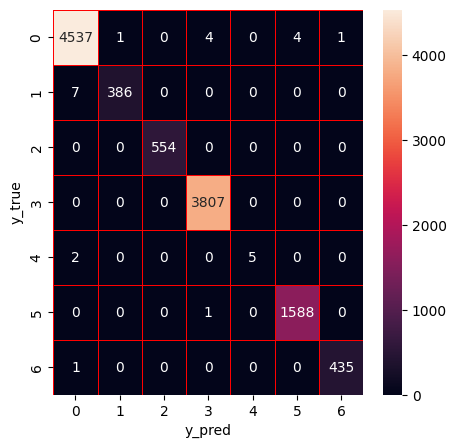

In [45]:
# Ensemble method 3: hybrid stacking

# Get the predictions and prediction probabilities of the top-3 models
top_3_train_predictions = [globals()[model.lower() + '_train'] for model in top_3_models]
top_3_test_predictions = [globals()[model.lower() + '_test'] for model in top_3_models]

top_3_train_proba = [globals()[model.lower() + '_prob_train'] for model in top_3_models]
top_3_test_proba = [globals()[model.lower() + '_prob_test'] for model in top_3_models]

# Combine the predictions and prediction probabilities of the top-3 models
x_train = np.concatenate(top_3_train_predictions + top_3_train_proba, axis=1)
x_test = np.concatenate(top_3_test_predictions + top_3_test_proba, axis=1)

# Train and evaluate the stacking model
# calcualte the traning time
start_time = time.time()
#stk = lgb.LGBMClassifier().fit(x_train, y_train)
stk =  xgb.XGBClassifier(random_state=0).fit(x_train, y_train)
end_time = time.time()
stk_time = end_time - start_time
print('Training time of Stacking: '+ str(stk_time))

# calcualte the testing time per sample in milliseconds
start_time = time.time()
y_predict=stk.predict(x_test)
end_time = time.time()
stk_time = (end_time - start_time)/len(x_test)*1000
print('Testing time of Stacking: '+ str(stk_time))

y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

## Automated Feature Selection

In [46]:
# Save the feature importance lists generated by base ML algorithms
dt_feature = dt.feature_importances_
rf_feature = rf.feature_importances_
et_feature = et.feature_importances_
xg_feature = xg.feature_importances_
lgbm_feature = lgbm.feature_importances_
cat_feature = cat.feature_importances_

In [47]:
lgbm_feature = lgbm_feature/sum(lgbm_feature)
cat_feature = cat_feature/sum(cat_feature)

In [48]:
# Get the feature importances of the top-3 models
top_3_importances = [globals()[model.lower() + '_feature'] for model in top_3_models]

# Calculate the average importance of each feature
avg_feature = np.mean(top_3_importances, axis=0)

feature=(df.drop(['Label'],axis=1)).columns.values
print ("Features sorted by their score:")
print (sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True))

f_list = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)


Features sorted by their score:
[(0.1227, 'Bwd Packet Length Min'), (0.0767, 'Bwd Packet Length Std'), (0.0567, 'Init_Win_bytes_forward'), (0.0529, 'Average Packet Size'), (0.0507, 'Init_Win_bytes_backward'), (0.0425, 'PSH Flag Count'), (0.0359, 'Bwd Packets/s'), (0.0293, 'Avg Bwd Segment Size'), (0.0283, 'Fwd Header Length'), (0.0281, 'Bwd Header Length'), (0.0257, 'Packet Length Mean'), (0.0227, 'Packet Length Std'), (0.0212, 'Fwd PSH Flags'), (0.0206, 'Packet Length Variance'), (0.0186, 'Bwd Packet Length Mean'), (0.0174, 'Fwd Header Length.1'), (0.0165, 'min_seg_size_forward'), (0.0149, 'Flow Bytes/s'), (0.0148, 'Flow IAT Min'), (0.0147, 'Total Length of Fwd Packets'), (0.0147, 'Max Packet Length'), (0.0146, 'Bwd Packet Length Max'), (0.0139, 'Total Length of Bwd Packets'), (0.0135, 'Fwd Packet Length Mean'), (0.0127, 'Avg Fwd Segment Size'), (0.0118, 'Fwd Packet Length Max'), (0.0117, 'Fwd IAT Min'), (0.0102, 'Total Fwd Packets'), (0.0101, 'Subflow Bwd Bytes'), (0.01, 'Subflow Fwd

In [49]:
# Select the important features from top-importance to bottom-importance until the accumulated importance reaches 0.9 (out of 1)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])
    if Sum>=0.9:
        break        

In [50]:
# regenerate the training and test sets with the selected features

X_fs = df[fs].values
X_train, X_test, y_train, y_test = train_test_split(X_fs,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [51]:
X_train.shape

(45328, 39)

In [52]:
# save the dataset with the selected features
df_fs = pd.DataFrame(X_fs, columns=fs)
df_fs['Label'] = y
df_fs.to_csv('/content/drive/My Drive/Colab Notebooks/Assignment/Data/CICIDS2017_sample_0.02_fs.csv', index=False)

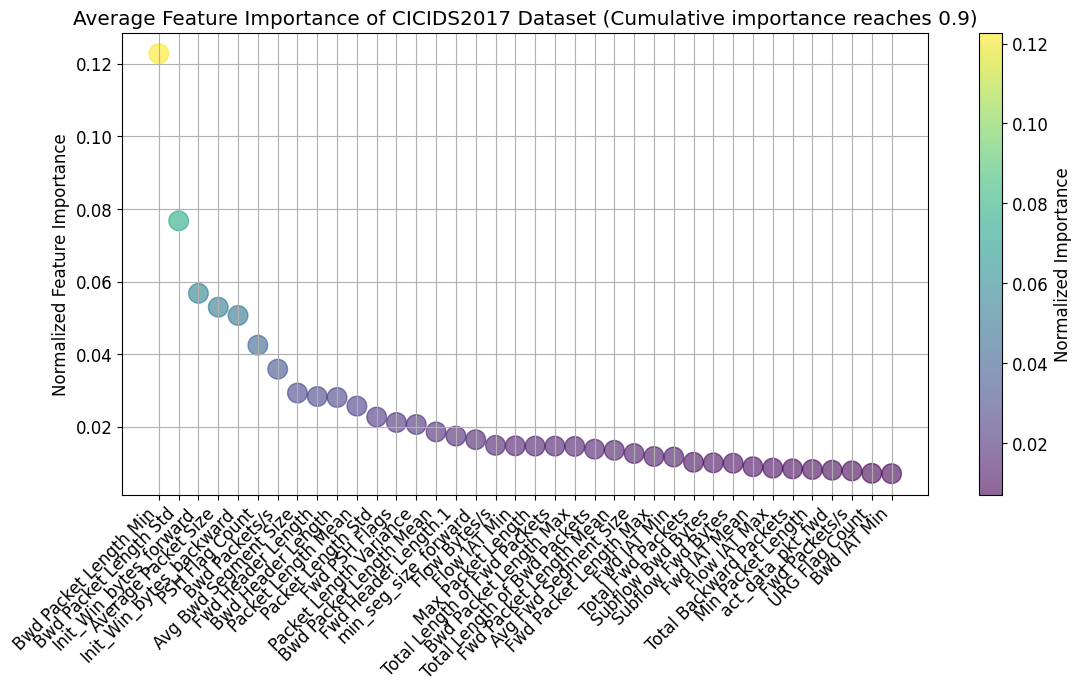

In [53]:
# Plot the feature importance of the top-3 models
plt.rcParams.update({'font.size': 12})

# Create a DataFrame for easier plotting
features = pd.DataFrame({
    'Feature': df.drop(['Label'],axis=1).columns,
    'Importance': avg_feature
})

# Sort features by importance
features = features.sort_values(by='Importance', ascending=False)

# Calculate cumulative importance and filter features
features['Cumulative'] = features['Importance'].cumsum()
filtered_features = features[features['Cumulative'] <= 0.9]

# Plotting
plt.figure(figsize=(13, 6))
scatter = plt.scatter(x='Feature', y='Importance', s=200, c='Importance', cmap='viridis', alpha=0.6, data=filtered_features)
plt.colorbar(scatter, label='Normalized Importance')
plt.xticks(rotation=45, ha='right')
plt.title('Average Feature Importance of CICIDS2017 Dataset (Cumulative importance reaches 0.9)')
plt.ylabel('Normalized Feature Importance')
plt.grid(True)
plt.show()

### Data Balancing by Proposed TVAE-based Method

In [54]:
pd.Series(y_train).value_counts()

0    18184
3    15228
5     6357
2     2213
6     1744
1     1573
4       29
Name: count, dtype: int64

In [55]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_csv(filepath='/content/drive/My Drive/Colab Notebooks/Assignment/Data/CICIDS2017_sample_0.02_fs.csv')


In [56]:
# Ensure all columns in df are numeric before splitting
from sklearn.preprocessing import LabelEncoder
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

training_set, test_set = train_test_split(df, test_size = 0.2, random_state = 0, stratify = df['Label'])
X_train = training_set[fs].values.astype(np.float64)
y_train = training_set['Label'].values
X_test = test_set[fs].values.astype(np.float64)
y_test = test_set['Label'].values


In [57]:
training_set['Label'].value_counts()

Label
0    18184
3    15228
5     6357
2     2213
6     1744
1     1573
4       29
Name: count, dtype: int64

In [58]:
from sdv.single_table import TVAESynthesizer
# Identify the average number of samples per class
average_samples = pd.Series(y_train).value_counts().mean()

# Identify minority classes with less than half the average number of samples
minority_classes = pd.Series(y_train).value_counts()
minority_classes = minority_classes[minority_classes < average_samples / 2].index.tolist()

# Prepare an empty DataFrame to collect synthetic data
synthetic_data = pd.DataFrame()

In [59]:
# Generating synthetic samples for each minority class using TVAE
for cls in minority_classes:
    cls_samples = X_train[y_train == cls]
    num_samples_needed = int(average_samples - len(cls_samples))
    
    # Initialize the TVAE model with detected metadata
    tvaegan = TVAESynthesizer(metadata=metadata)
    
    # Convert to DataFrame with Label for TVAE fitting
    cls_df = pd.DataFrame(cls_samples, columns=fs)
    cls_df['Label'] = y_train[y_train == cls]
    tvaegan.fit(cls_df)
    
    # Generate synthetic instances to match the average class sample size
    new_samples = tvaegan.sample(num_samples_needed)
    
    # Append the new synthetic instances to the synthetic data list
    synthetic_data = pd.concat([synthetic_data, new_samples], ignore_index=True)


# Save Phase 2 TVAE Synthesizer Model
os.makedirs(model_dir + 'phase2_tvae_synthesizer', exist_ok=True)
tvaegan.save(model_dir + 'phase2_tvae_synthesizer/tvae_synthesizer.pkl')
print('Phase 2: TVAE Data Balancing Synthesizer saved successfully to Google Drive!')


In [61]:
# Concatenate the original and synthetic data to form a balanced dataset
X_tr_df = pd.DataFrame(X_train, columns=fs)
X_tr_df['Label'] = y_train
balanced_data = pd.concat([X_tr_df, synthetic_data], ignore_index=True)

# Display the new distribution of labels in the balanced dataset
print(balanced_data['Label'].value_counts())

# Ensure all features in balanced_data are numeric float64
for col in balanced_data.columns:
    if col != 'Label' and (balanced_data[col].dtype == 'object' or balanced_data[col].dtype.name == 'category'):
        balanced_data[col] = LabelEncoder().fit_transform(balanced_data[col].astype(str))

# Prepare the balanced dataset for model training
X_train_balanced = balanced_data.drop(['Label'], axis=1).values.astype(np.float64)
y_train_balanced = balanced_data['Label'].values


Label
0    18184
3    15228
2     6475
6     6475
1     6475
4     6475
5     6357
Name: count, dtype: int64


## Machine learning model training

### Training six base learners: 
decision tree, random forest, extra trees, XGBoost, LightGBM, and CatBoost


### Cross-validation

### DT

Training time:  0.8667712211608887
Prediction time per sample:  0.00026404231768320047
Cross-Validation scores:  [0.94613979 0.99547739 0.99470053]
Mean of Cross-Validation scores:  0.9787725704360364
Accuracy of DT: 0.9947939645283684
Precision of DT: 0.9948133440436601
Recall of DT: 0.9947939645283684
F1-score of DT: 0.9947939491571862
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4547
           1       0.98      0.98      0.98       393
           2       0.98      1.00      0.99       554
           3       1.00      1.00      1.00      3807
           4       0.86      0.86      0.86         7
           5       1.00      1.00      1.00      1589
           6       0.99      0.99      0.99       436

    accuracy                           0.99     11333
   macro avg       0.97      0.97      0.97     11333
weighted avg       0.99      0.99      0.99     11333



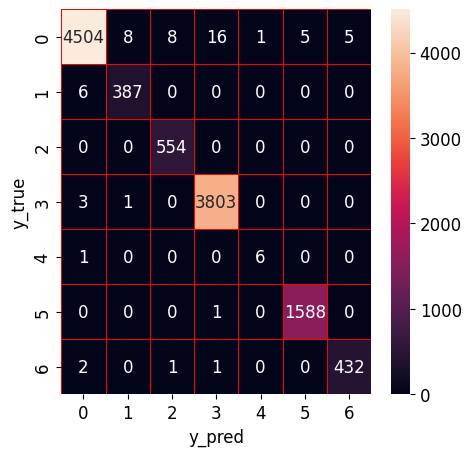

CPU times: total: 2.8 s
Wall time: 2.8 s


In [62]:
%%time
X_train_balanced = np.asarray(X_train_balanced, dtype=np.float64)
y_train_balanced = np.asarray(y_train_balanced)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
# Decision tree training and prediction with 3-fold cross-validation
dt = DecisionTreeClassifier(random_state=0)
dt_scores = cross_val_score(dt, X_train_balanced, y_train_balanced, cv=3)
# calculate the training time
start = time.time()
dt.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = dt.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test)*1000)
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', dt_scores)
print('Mean of Cross-Validation scores: ', np.mean(dt_scores))
# Evaluation metrics
dt_score = dt.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of DT: ' + str(dt_score))
print('Precision of DT: ' + str(precision))
print('Recall of DT: ' + str(recall))
print('F1-score of DT: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [00:30<00:00,  1.54s/trial, best loss: -0.9742956319828528]
Decision Tree: Hyperopt estimated optimum {'criterion': 'gini', 'max_depth': 26, 'min_samples_leaf': 2, 'min_samples_split': 2}
Accuracy of DT: 0.9948822024177182
Precision of DT: 0.9948915046168738
Recall of DT: 0.9948822024177182
F1-score of DT: 0.9948812479196358
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4547
           1       0.98      0.98      0.98       393
           2       0.98      1.00      0.99       554
           3       1.00      1.00      1.00      3807
           4       0.86      0.86      0.86         7
           5       1.00      1.00      1.00      1589
           6       0.99      0.99      0.99       436

    accuracy                           0.99     11333
   macro avg       0.97      0.97      0.97     11333
weighted avg       0.99      0.99      0.99     11333



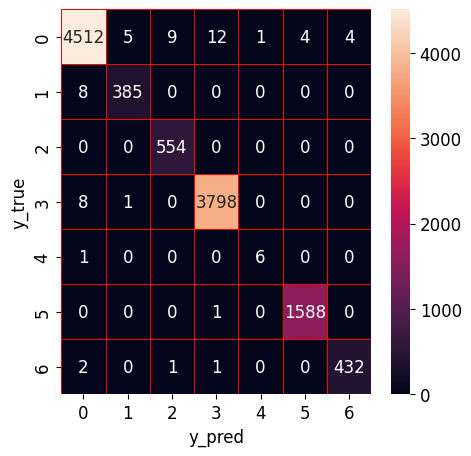

In [63]:
# Hyperparameter Optimization using BO-TPE

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'max_depth': int(params['max_depth']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'criterion': ['gini', 'entropy'][int(params['criterion'])]
    }
    clf = DecisionTreeClassifier(random_state=0, **params)
    score = cross_val_score(clf, X_train_balanced, y_train_balanced, scoring='accuracy', cv=StratifiedKFold(n_splits=3)).mean()

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'max_depth': hp.quniform('max_depth', 1, 50, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 11, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 11, 1),
    'criterion': hp.choice('criterion', [0, 1])  # 0 for 'gini', 1 for 'entropy'
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['max_depth'] = int(best['max_depth'])
best['min_samples_split'] = int(best['min_samples_split'])
best['min_samples_leaf'] = int(best['min_samples_leaf'])
best['criterion'] = ['gini', 'entropy'][int(best['criterion'])]

print("Decision Tree: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
dt = DecisionTreeClassifier(random_state=0, **best)
dt.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = dt.predict(X_test)
y_true = y_test

# Evaluation metrics
dt_score = dt.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of DT: ' + str(dt_score))
print('Precision of DT: ' + str(precision))
print('Recall of DT: ' + str(recall))
print('F1-score of DT: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### RF

Training time:  11.820600748062134
Prediction time:  0.010911252674711021 ms
Cross-Validation scores:  [0.93225217 0.99803563 0.99771575]
Mean of Cross-Validation scores:  0.9760011834284702
Accuracy of RF: 0.9965587223153622
Precision of RF: 0.9965554790789681
Recall of RF: 0.9965587223153622
F1-score of RF: 0.9965392815440419
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.97      0.98       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      0.99      0.99       436

    accuracy                           1.00     11333
   macro avg       1.00      0.95      0.97     11333
weighted avg       1.00      1.00      1.00     11333



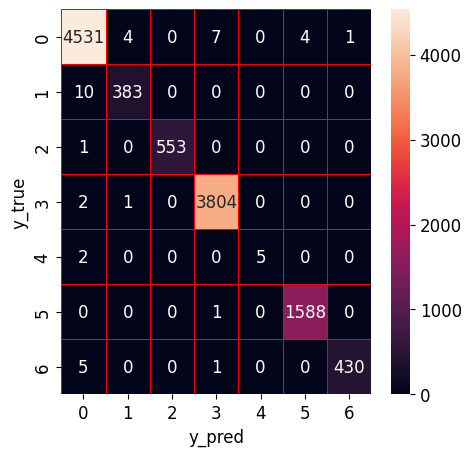

CPU times: total: 35.2 s
Wall time: 35.2 s


In [64]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Random Forest training and prediction with 3-fold cross-validation
rf = RandomForestClassifier(random_state=0)
rf_scores = cross_val_score(rf, X_train_balanced, y_train_balanced, cv=3)
# calculate the training time
start = time.time()
rf.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = rf.predict(X_test)
end = time.time()
print('Prediction time: ', (end - start) / len(y_predict) * 1000, 'ms')
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', rf_scores)
print('Mean of Cross-Validation scores: ', np.mean(rf_scores))
# Evaluation metrics
rf_score = rf.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of RF: ' + str(rf_score))
print('Precision of RF: ' + str(precision))
print('Recall of RF: ' + str(recall))
print('F1-score of RF: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [23:44<00:00, 71.24s/trial, best loss: -0.9771584830012561] 
Random Forest: Hyperopt estimated optimum {'criterion': 'gini', 'max_depth': 48, 'max_features': 27, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 106}
Accuracy of RF: 0.9963822465366629
Precision of RF: 0.9963830505233648
Recall of RF: 0.9963822465366629
F1-score of RF: 0.9963812892121173
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.99      0.99       393
           2       0.99      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       0.71      0.71      0.71         7
           5       1.00      1.00      1.00      1589
           6       1.00      0.99      1.00       436

    accuracy                           1.00     11333
   macro avg       0.96      0.95      0.95     11333
weighted avg       1.00      1.00      1.00     11333



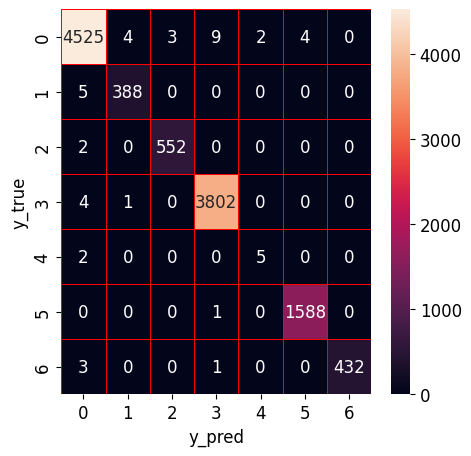

In [65]:
# Hyperparameter Optimization using BO-TPE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'criterion': ['gini', 'entropy'][int(params['criterion'])]
    }
    clf = RandomForestClassifier(random_state=0, **params)
    score = cross_val_score(clf, X_train_balanced, y_train_balanced, scoring='accuracy', cv=StratifiedKFold(n_splits=3)).mean()

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 200, 1),
    'max_depth': hp.quniform('max_depth', 5, 50, 1),
    "max_features":hp.quniform('max_features', 1, 40, 1),
    "min_samples_split":hp.quniform('min_samples_split',2,11,1),
    "min_samples_leaf":hp.quniform('min_samples_leaf',1,11,1),
    'criterion': hp.choice('criterion', [0, 1])  # 0 for 'gini', 1 for 'entropy'
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['max_features'] = int(best['max_features'])
best['min_samples_split'] = int(best['min_samples_split'])
best['min_samples_leaf'] = int(best['min_samples_leaf'])
best['criterion'] = ['gini', 'entropy'][int(best['criterion'])]

print("Random Forest: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
rf = RandomForestClassifier(random_state=0, **best)
rf.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = rf.predict(X_test)
y_true = y_test

# Evaluation metrics
rf_score = rf.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of RF: ' + str(rf_score))
print('Precision of RF: ' + str(precision))
print('Recall of RF: ' + str(recall))
print('F1-score of RF: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### ET

Training time:  3.0809121131896973
Prediction time:  0.01232306176541311 ms
Cross-Validation scores:  [0.9241206  0.99639105 0.99657362]
Mean of Cross-Validation scores:  0.9723617568695211
Accuracy of ET: 0.9928527309626753
Precision of ET: 0.9928793046554231
Recall of ET: 0.9928527309626753
F1-score of ET: 0.9928558149251036
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4547
           1       0.95      0.97      0.96       393
           2       0.99      1.00      0.99       554
           3       1.00      1.00      1.00      3807
           4       0.71      0.71      0.71         7
           5       1.00      1.00      1.00      1589
           6       0.99      0.97      0.98       436

    accuracy                           0.99     11333
   macro avg       0.95      0.95      0.95     11333
weighted avg       0.99      0.99      0.99     11333



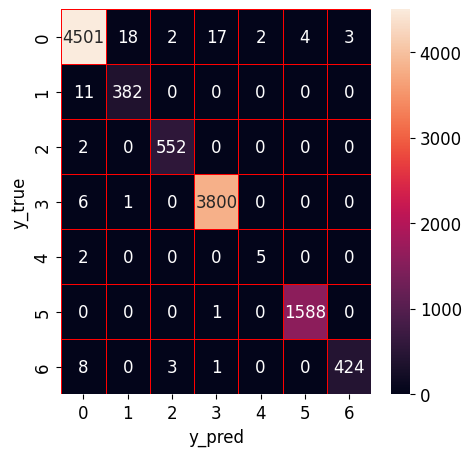

CPU times: total: 10 s
Wall time: 10 s


In [66]:
%%time
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Extra Trees training and prediction with 3-fold cross-validation
et = ExtraTreesClassifier(random_state=0)
et_scores = cross_val_score(et, X_train_balanced, y_train_balanced, cv=3)
# calculate the training time
start = time.time()
et.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = et.predict(X_test)
end = time.time()
print('Prediction time: ', (end - start) / len(X_test) * 1000, 'ms')
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', et_scores)
print('Mean of Cross-Validation scores: ', np.mean(et_scores))
# Evaluation metrics
et_score = et.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of ET: ' + str(et_score))
print('Precision of ET: ' + str(precision))
print('Recall of ET: ' + str(recall))
print('F1-score of ET: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [02:34<00:00,  7.75s/trial, best loss: -0.9750875235276776]
Extra Trees: Hyperopt estimated optimum {'criterion': 'entropy', 'max_depth': 44, 'max_features': 17, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 165}
Accuracy of ET: 0.9958528192005647
Precision of ET: 0.9958556363121698
Recall of ET: 0.9958528192005647
F1-score of ET: 0.9958374839444892
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4547
           1       0.97      0.97      0.97       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      0.99      0.99       436

    accuracy                           1.00     11333
   macro avg       0.99      0.95      0.97     11333
weighted avg       1.00      1.00      1.00     11333



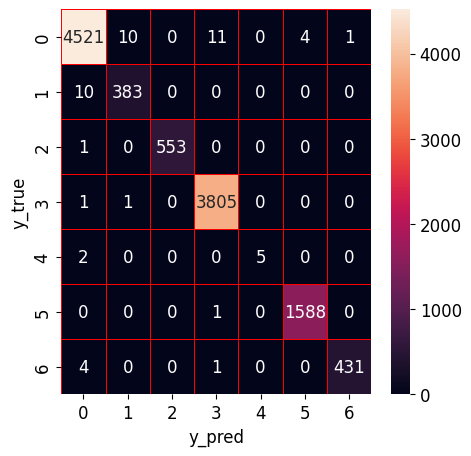

In [67]:
# Hyperparameter Optimization using BO-TPE

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'criterion': ['gini', 'entropy'][int(params['criterion'])]
    }
    clf = ExtraTreesClassifier(random_state=0, **params)
    score = cross_val_score(clf, X_train_balanced, y_train_balanced, scoring='accuracy', cv=StratifiedKFold(n_splits=3)).mean()

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 200, 1),
    'max_depth': hp.quniform('max_depth', 1, 50, 1),
    'max_features': hp.quniform('max_features', 1, 20, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 11, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 11, 1),
    'criterion': hp.choice('criterion', [0, 1])  # 0 for 'gini', 1 for 'entropy'
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['max_features'] = int(best['max_features'])
best['min_samples_split'] = int(best['min_samples_split'])
best['min_samples_leaf'] = int(best['min_samples_leaf'])
best['criterion'] = ['gini', 'entropy'][int(best['criterion'])]

print("Extra Trees: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
et = ExtraTreesClassifier(random_state=0, **best)
et.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = et.predict(X_test)
y_true = y_test

# Evaluation metrics
et_score = et.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of ET: ' + str(et_score))
print('Precision of ET: ' + str(precision))
print('Recall of ET: ' + str(recall))
print('F1-score of ET: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### XGBoost

Training time:  14.824193000793457
Prediction time per sample:  0.0015841066432337912
Cross-Validation scores:  [0.93777981 0.99858383 0.99844671]
Mean of Cross-Validation scores:  0.97827011491866
Accuracy of XGBoost: 0.9978822906556075
Precision of XGBoost: 0.9978810452476734
Recall of XGBoost: 0.9978822906556075
F1-score of XGBoost: 0.9978661481364945
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



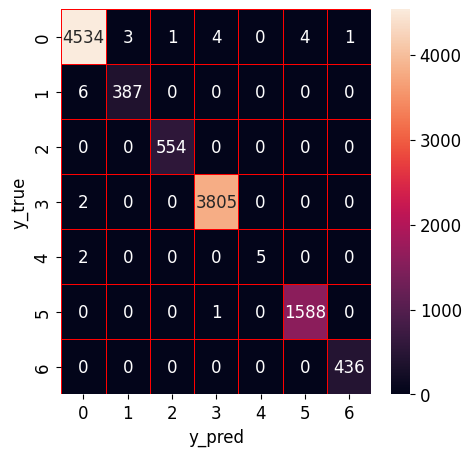

In [68]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# XGBoost training and prediction with 3-fold cross-validation
xg = xgb.XGBClassifier(random_state=0)
xg_scores = cross_val_score(xg, X_train_balanced, y_train_balanced, cv=3)

# calculate the training time
start = time.time()
xg.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = xg.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)


y_true = y_test

# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', xg_scores)
print('Mean of Cross-Validation scores: ', np.mean(xg_scores))

# Evaluation metrics
xg_score = xg.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of XGBoost: ' + str(xg_score))
print('Precision of XGBoost: ' + str(precision))
print('Recall of XGBoost: ' + str(recall))
print('F1-score of XGBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [03:22<00:00, 10.14s/trial, best loss: -0.9977940527662579]
XGBoost: Hyperopt estimated optimum {'learning_rate': 0.4879676682780232, 'max_depth': 32, 'n_estimators': 65}
Accuracy of XGBoost: 0.9977940527662579
Precision of XGBoost: 0.9977929515415213
Recall of XGBoost: 0.9977940527662579
F1-score of XGBoost: 0.9977779063989407
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



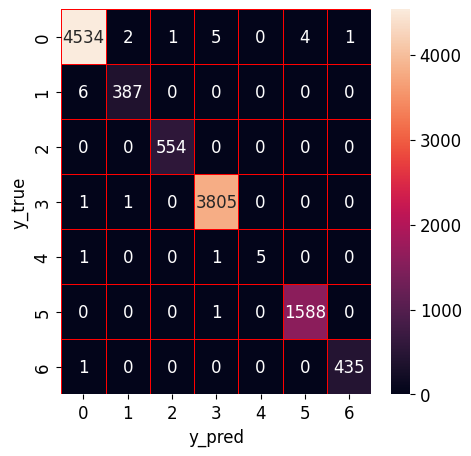

In [69]:
# Hyperparameter Optimization using BO-TPE

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': abs(float(params['learning_rate']))
    }
    clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=0, **params)
    clf.fit(X_train_balanced, y_train_balanced)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 100, 5),
    'max_depth': hp.quniform('max_depth', 4, 100, 1),
    'learning_rate': hp.normal('learning_rate', 0.01, 0.9)
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['learning_rate'] = abs(float(best['learning_rate']))

print("XGBoost: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
xg = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=0, **best)
xg.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = xg.predict(X_test)
y_true = y_test

# Evaluation metrics
xg_score = xg.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of XGBoost: ' + str(xg_score))
print('Precision of XGBoost: ' + str(precision))
print('Recall of XGBoost: ' + str(recall))
print('F1-score of XGBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### LightGBM

Training time:  1.820234775543213
Prediction time per sample:  0.004224340482095981
Cross-Validation scores:  [0.93805391 0.99830973 0.99867513]
Mean of Cross-Validation scores:  0.9783462566641332
Accuracy of LightGBM: 0.9977058148769081
Precision of LightGBM: 0.9977046875647071
Recall of LightGBM: 0.9977058148769081
F1-score of LightGBM: 0.997688878348638
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



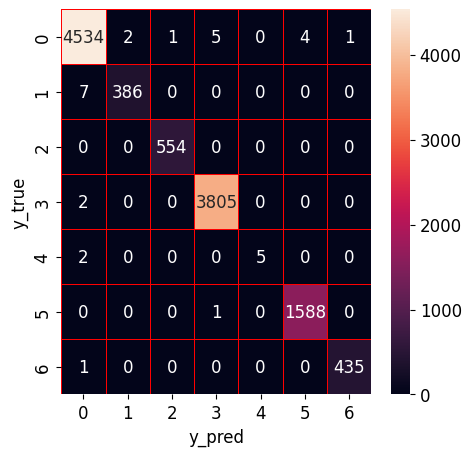

In [70]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# LightGBM training and prediction with 3-fold cross-validation
lgbm = lgb.LGBMClassifier(random_state=0)
lgbm_scores = cross_val_score(lgbm, X_train_balanced, y_train_balanced, cv=3)

# calculate the training time
start = time.time()
lgbm.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = lgbm.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)



y_true = y_test

# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', lgbm_scores)
print('Mean of Cross-Validation scores: ', np.mean(lgbm_scores))

# Evaluation metrics
lgbm_score = lgbm.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of LightGBM: ' + str(lgbm_score))
print('Precision of LightGBM: ' + str(precision))
print('Recall of LightGBM: ' + str(recall))
print('F1-score of LightGBM: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [00:24<00:00,  1.25s/trial, best loss: -0.9976175769875585]
LightGBM: Hyperopt estimated optimum {'learning_rate': 0.5548389313548716, 'max_depth': 100, 'min_child_samples': 60, 'n_estimators': 15, 'num_leaves': 45}
Accuracy of LightGBM: 0.9976175769875585
Precision of LightGBM: 0.9976153756950639
Recall of LightGBM: 0.9976175769875585
F1-score of LightGBM: 0.9976000971566817
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



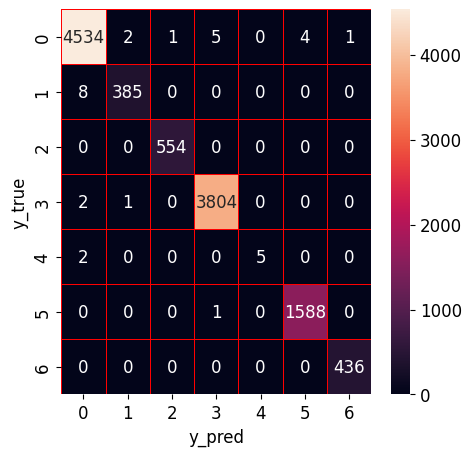

In [71]:
# Hyperparameter Optimization using BO-TPE

import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': abs(float(params['learning_rate'])),
        'num_leaves': int(params['num_leaves']),
        'min_child_samples': int(params['min_child_samples'])
    }
    clf = lgb.LGBMClassifier(random_state=0, **params)
    clf.fit(X_train_balanced, y_train_balanced)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 100, 5),
    'max_depth': hp.quniform('max_depth', 4, 100, 1),
    'learning_rate': hp.normal('learning_rate', 0.01, 0.9),
    'num_leaves': hp.quniform('num_leaves', 10, 200, 5),
    'min_child_samples': hp.quniform('min_child_samples', 5, 100, 5)
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['learning_rate'] = abs(float(best['learning_rate']))
best['num_leaves'] = int(best['num_leaves'])
best['min_child_samples'] = int(best['min_child_samples'])

print("LightGBM: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
lgbm = lgb.LGBMClassifier(random_state=0, **best)
lgbm.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = lgbm.predict(X_test)
y_true = y_test

# Evaluation metrics
lgbm_score = lgbm.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of LightGBM: ' + str(lgbm_score))
print('Precision of LightGBM: ' + str(precision))
print('Recall of LightGBM: ' + str(recall))
print('F1-score of LightGBM: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### CatBoost

Training time:  30.027976274490356
Prediction time per sample:  0.0011441062389357958
Cross-Validation scores:  [0.93714025 0.99826405 0.99794417]
Mean of Cross-Validation scores:  0.9777828223568278
Accuracy of CatBoost: 0.9971763875408101
Precision of CatBoost: 0.997176647229068
Recall of CatBoost: 0.9971763875408101
F1-score of CatBoost: 0.9971395429633921
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.57      0.73         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.94      0.96     11333
weighted avg       1.00      1.00      1.00     11333



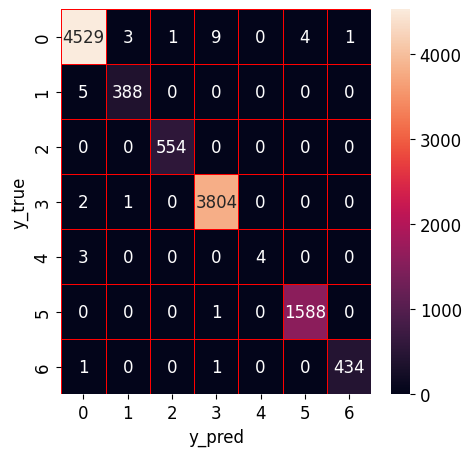

In [72]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# CatBoost training and prediction with 3-fold cross-validation
cat = CatBoostClassifier(random_state=0, verbose=False)
cat_scores = cross_val_score(cat, X_train_balanced, y_train_balanced, cv=3)


# calculate the training time
start = time.time()
cat.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = cat.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)


# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', cat_scores)
print('Mean of Cross-Validation scores: ', np.mean(cat_scores))

# Evaluation metrics
cat_score = cat.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of CatBoost: ' + str(cat_score))
print('Precision of CatBoost: ' + str(precision))
print('Recall of CatBoost: ' + str(recall))
print('F1-score of CatBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 2/2 [00:33<00:00, 16.78s/trial, best loss: -0.9973528633195095]
CatBoost: Hyperopt estimated optimum {'depth': 5, 'iterations': 1000, 'learning_rate': 0.14113171790500412}
Accuracy of CatBoost: 0.9973528633195095
Precision of CatBoost: 0.997352745186135
Recall of CatBoost: 0.9973528633195095
F1-score of CatBoost: 0.9973375383121329
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.99      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



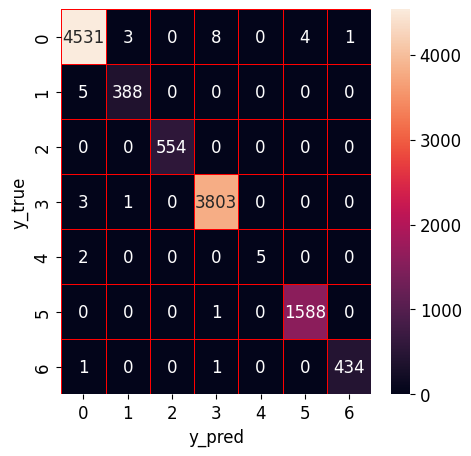

In [73]:
# Hyperparameter Optimization using BO-TPE

import catboost as cb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'depth': int(params['depth']),
        'learning_rate': params['learning_rate'],
        'iterations': int(params['iterations'])
    }
    clf = cb.CatBoostClassifier(random_state=0, verbose=False, **params)
    clf.fit(X_train_balanced, y_train_balanced)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'depth': hp.quniform('depth', 2, 12, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.5),
    'iterations': hp.quniform('iterations', 100, 1000, 100)
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=2)

# Convert the returned hyperparameters to their original types
best['depth'] = int(best['depth'])
best['learning_rate'] = best['learning_rate']
best['iterations'] = int(best['iterations'])

print("CatBoost: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
cat = cb.CatBoostClassifier(random_state=0, verbose=False, **best)
cat.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = cat.predict(X_test)
y_true = y_test

# Evaluation metrics
cat_score = cat.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of CatBoost: ' + str(cat_score))
print('Precision of CatBoost: ' + str(precision))
print('Recall of CatBoost: ' + str(recall))
print('F1-score of CatBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


In [74]:
# record the results
dt_train=dt.predict(X_train_balanced)
dt_test=dt.predict(X_test)
dt_prob_train=dt.predict_proba(X_train_balanced)
dt_prob_test=dt.predict_proba(X_test)

rf_train=rf.predict(X_train_balanced)
rf_test=rf.predict(X_test)
rf_prob_train=rf.predict_proba(X_train_balanced)
rf_prob_test=rf.predict_proba(X_test)

et_train=et.predict(X_train_balanced)
et_test=et.predict(X_test)
et_prob_train=et.predict_proba(X_train_balanced)
et_prob_test=et.predict_proba(X_test)

xg_train=xg.predict(X_train_balanced)
xg_test=xg.predict(X_test)
xg_prob_train=xg.predict_proba(X_train_balanced)
xg_prob_test=xg.predict_proba(X_test)

lgbm_train=lgbm.predict(X_train_balanced)
lgbm_test=lgbm.predict(X_test)
lgbm_prob_train=lgbm.predict_proba(X_train_balanced)
lgbm_prob_test=lgbm.predict_proba(X_test)

cat_train=cat.predict(X_train_balanced)
cat_test=cat.predict(X_test)
cat_prob_train=cat.predict_proba(X_train_balanced)
cat_prob_test=cat.predict_proba(X_test)


# Save Phase 3 Final Base Models
os.makedirs(model_dir + 'phase3_final_base_models', exist_ok=True)
joblib.dump(dt, model_dir + 'phase3_final_base_models/dt_final.joblib')
joblib.dump(rf, model_dir + 'phase3_final_base_models/rf_final.joblib')
joblib.dump(et, model_dir + 'phase3_final_base_models/et_final.joblib')
joblib.dump(xg, model_dir + 'phase3_final_base_models/xg_final.joblib')
joblib.dump(lgbm, model_dir + 'phase3_final_base_models/lgbm_final.joblib')
joblib.dump(cat, model_dir + 'phase3_final_base_models/cat_final.joblib')
print('Phase 3: Final Base Models saved successfully to Google Drive!')

## Model selection

In [75]:
# Calculate the performance of each base model (e.g., accuracy)
base_model_performance = {
    'dt': np.mean(dt_scores),
    'rf': np.mean(rf_scores),
    'et': np.mean(et_scores),
    'xg': np.mean(xg_scores),
    'lgbm': np.mean(lgbm_scores),
    'cat': np.mean(cat_scores)

}

# Rank the base models based on their performance
ranked_models = sorted(base_model_performance, key=base_model_performance.get, reverse=True)

# Select the top-3 performing base models
top_3_models = ranked_models[:3]



In [76]:
top_3_models

['dt', 'lgbm', 'xg']

In [77]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
lgbm_train=lgbm_train.reshape(-1, 1)
cat_train=cat_train.reshape(-1, 1)


dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)
lgbm_test=lgbm_test.reshape(-1, 1)
cat_test=cat_test.reshape(-1, 1)

Accuracy of Stacking: 0.9978822906556075
Precision of Stacking: 0.997881313485891
Recall of Stacking: 0.9978822906556075
F1-score of Stacking: 0.9978661122587069
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



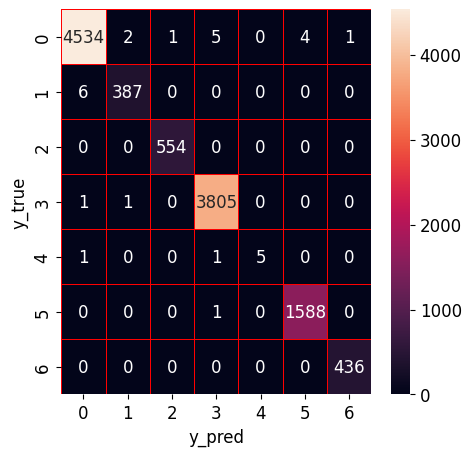

In [78]:
# Ensemble method 1: traditional stacking

# Get the predictions of the top-3 models
top_3_train_predictions = [globals()[model.lower() + '_train'] for model in top_3_models]
top_3_test_predictions = [globals()[model.lower() + '_test'] for model in top_3_models]

# Stack the predictions of the top-3 models
X_train_balanced = np.concatenate(top_3_train_predictions, axis=1)
x_test = np.concatenate(top_3_test_predictions, axis=1)

# Train and evaluate the stacking model
stk = lgb.LGBMClassifier().fit(X_train_balanced, y_train_balanced)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


Accuracy of Stacking: 0.9973528633195095
Precision of Stacking: 0.9973531762405455
Recall of Stacking: 0.9973528633195095
F1-score of Stacking: 0.9973516745314188
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       0.86      0.86      0.86         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       0.98      0.98      0.98     11333
weighted avg       1.00      1.00      1.00     11333



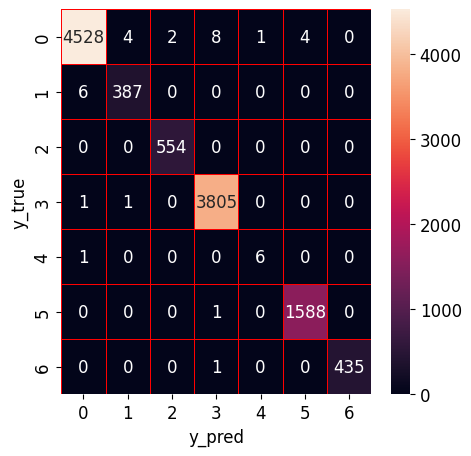

In [79]:
# Ensemble method 2: confidence-based stacking

# Get the prediction probabilities of the top-3 models
top_3_train_proba = [globals()[model.lower() + '_prob_train'] for model in top_3_models]
top_3_test_proba = [globals()[model.lower() + '_prob_test'] for model in top_3_models]

# Stack the predictions and prediction probabilities of the top-3 models
X_train_balanced = np.concatenate(top_3_train_proba, axis=1)
x_test = np.concatenate(top_3_test_proba, axis=1)

# Train and evaluate the stacking model
stk = lgb.LGBMClassifier().fit(X_train_balanced, y_train_balanced)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

Accuracy of Stacking: 0.9977940527662579
Precision of Stacking: 0.9977928768369768
Recall of Stacking: 0.9977940527662579
F1-score of Stacking: 0.9977779450001537
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4547
           1       0.99      0.98      0.99       393
           2       1.00      1.00      1.00       554
           3       1.00      1.00      1.00      3807
           4       1.00      0.71      0.83         7
           5       1.00      1.00      1.00      1589
           6       1.00      1.00      1.00       436

    accuracy                           1.00     11333
   macro avg       1.00      0.96      0.97     11333
weighted avg       1.00      1.00      1.00     11333



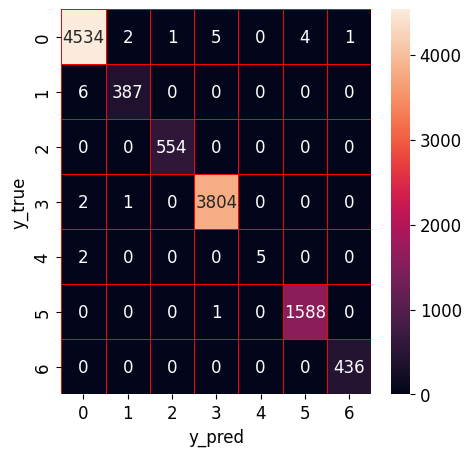

In [80]:
# Ensemble method 3: hybrid stacking
# Get the predictions and prediction probabilities of the top-3 models
top_3_train_predictions = [globals()[model.lower() + '_train'] for model in top_3_models]
top_3_test_predictions = [globals()[model.lower() + '_test'] for model in top_3_models]

top_3_train_proba = [globals()[model.lower() + '_prob_train'] for model in top_3_models]
top_3_test_proba = [globals()[model.lower() + '_prob_test'] for model in top_3_models]

# Combine the predictions and prediction probabilities of the top-3 models
X_train_balanced = np.concatenate(top_3_train_predictions + top_3_train_proba, axis=1)
x_test = np.concatenate(top_3_test_predictions + top_3_test_proba, axis=1)

# Train and evaluate the stacking model
stk = lgb.LGBMClassifier().fit(X_train_balanced, y_train_balanced)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

# PS: the hyperparameter optimization process is the same as the previous steps

# Save Phase 4 Final OCSE Stacking Ensemble Model
os.makedirs(model_dir + 'phase4_stacking_ensemble', exist_ok=True)
joblib.dump(stk, model_dir + 'phase4_stacking_ensemble/stk_final_ocse.joblib')
print('Phase 4: Final OCSE Stacking Ensemble Model saved successfully to Google Drive!')

---

# Dataset 2: 5G-NIDD

---

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# Re-initialize variables for Dataset 2
# Clear Dataset 1 state to prevent cross-contamination
# ═══════════════════════════════════════════════════════════════════
import gc
for var in ['df', 'X', 'y', 'X_train', 'X_test', 'y_train', 'y_test',
            'X_fs', 'fs', 'df_fs', 'X_train_balanced', 'y_train_balanced',
            'training_set', 'test_set', 'balanced_data', 'synthetic_data',
            'dt', 'rf', 'et', 'xg', 'lgbm', 'cat', 'stk', 'tvaegan',
            'dt_train', 'dt_test', 'dt_prob_train', 'dt_prob_test',
            'rf_train', 'rf_test', 'rf_prob_train', 'rf_prob_test',
            'et_train', 'et_test', 'et_prob_train', 'et_prob_test',
            'xg_train', 'xg_test', 'xg_prob_train', 'xg_prob_test',
            'lgbm_train', 'lgbm_test', 'lgbm_prob_train', 'lgbm_prob_test',
            'cat_train', 'cat_test', 'cat_prob_train', 'cat_prob_test',
            'top_3_models', 'metadata', 'model_dir']:
    if var in globals():
        del globals()[var]
gc.collect()
print('Dataset 1 state cleared. Ready for Dataset 2.')


## Dataset 2: 5G-NIDD
The 5G-NIDD dataset is publicly available at: https://ieee-dataport.org/documents/5g-nidd-comprehensive-network-intrusion-detection-dataset-generated-over-5g-wireless 

Due to the large size of this dataset and the file size limit of GitHub, the sampled subset of CICIDS2017 is used. The subsets are in the "Data" folder.  PS: The results might be different from the paper due to the size difference of the dataset.

The 5G-NIDD dataset, created in December 2022, is a fully labeled resource constructed on a functional 5G test network for researchers and practitioners evaluating AI/ML solutions in the context of 5G/6G security [87]. 5G-NIDD encompasses data extracted from a 5G testbed connected to the 5G Test Network (5GTN) at the University of Oulu, Finland. The dataset is derived from two base stations, each featuring an attacker node and multiple benign 5G users. The attacker nodes target a server deployed within the 5GTN MEC environment. The attack scenarios captured in the dataset primarily include DoS attacks and port scans.


### Load data

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [11]:
# Read the dataset
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/Assignment/Data/5G-NIDD_0.04.csv')

In [12]:
# print the class distribution of the last column
df['Label'].value_counts()

Label
0    19130
7    18351
1     5587
5     2848
4      856
6      790
8      647
3      386
2       41
Name: count, dtype: int64

### Data pre-processing

In [13]:
# Encode the dataset (Label & all string/categorical feature columns)
from sklearn.preprocessing import LabelEncoder

# Automatically detect and encode all string/object/categorical columns
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))

labelencoder = LabelEncoder()
if 'Label' in df.columns:
    df['Label'] = labelencoder.fit_transform(df['Label'])
else:
    df.iloc[:, -1] = labelencoder.fit_transform(df.iloc[:, -1])

# Address empty or infinite values if present
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

X = df.drop(['Label'], axis=1).values.astype(np.float64)
y = df['Label'].values if 'Label' in df.columns else df.iloc[:, -1].values
y = np.ravel(y)


In [14]:
# Split the dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(X,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

## Machine learning model training

### Training six base learners (for comparison purposes): 
decision tree, random forest, extra trees, XGBoost, LightGBM, and CatBoost


### Cross-validation

#### DT

Training time:  0.21639394760131836
Prediction time per sample:  0.00020832215484819914
Cross-Validation scores:  [0.99799537 0.99760968 0.99838075]
Mean of Cross-Validation scores:  0.9979952708927972
Accuracy of DT: 0.9985608552631579
Precision of DT: 0.9985728464490196
Recall of DT: 0.9985608552631579
F1-score of DT: 0.9985630659143901
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       0.89      1.00      0.94         8
           3       1.00      1.00      1.00        77
           4       1.00      0.99      1.00       171
           5       0.99      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       0.99      1.00      0.99      9728
weighted 

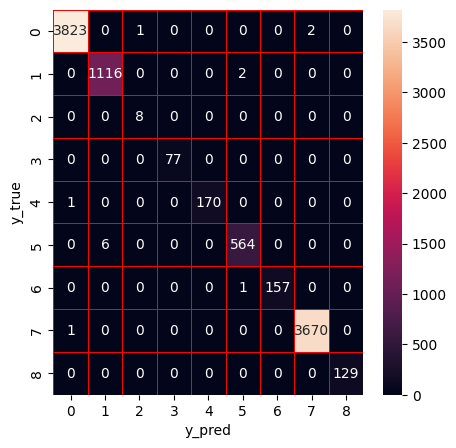

CPU times: total: 891 ms
Wall time: 885 ms


In [20]:
%%time
X_train = np.asarray(X_train, dtype=np.float64)
y_train = np.asarray(y_train)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
# Decision tree training and prediction with 3-fold cross-validation
dt = DecisionTreeClassifier(random_state=0)
dt_scores = cross_val_score(dt, X_train, y_train, cv=3)
# calculate the training time
start = time.time()
dt.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = dt.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test)*1000)
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', dt_scores)
print('Mean of Cross-Validation scores: ', np.mean(dt_scores))
# Evaluation metrics
dt_score = dt.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of DT: ' + str(dt_score))
print('Precision of DT: ' + str(precision))
print('Recall of DT: ' + str(recall))
print('F1-score of DT: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### RF

Training time:  3.4946563243865967
Prediction time:  0.007586700743750522 ms
Cross-Validation scores:  [0.99899769 0.99830365 0.99907472]
Mean of Cross-Validation scores:  0.9987920169201695
Accuracy of RF: 0.9991776315789473
Precision of RF: 0.9991778500646348
Recall of RF: 0.9991776315789473
F1-score of RF: 0.9991774273565044
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      1.00       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1

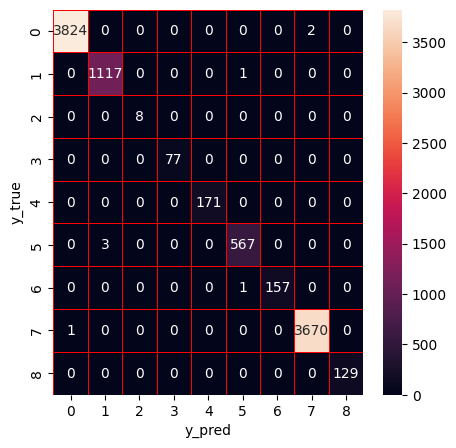

CPU times: total: 10.6 s
Wall time: 10.6 s


In [21]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Random Forest training and prediction with 3-fold cross-validation
rf = RandomForestClassifier(random_state=0)
rf_scores = cross_val_score(rf, X_train, y_train, cv=3)
# calculate the training time
start = time.time()
rf.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = rf.predict(X_test)
end = time.time()
print('Prediction time: ', (end - start) / len(y_predict) * 1000, 'ms')
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', rf_scores)
print('Mean of Cross-Validation scores: ', np.mean(rf_scores))
# Evaluation metrics
rf_score = rf.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of RF: ' + str(rf_score))
print('Precision of RF: ' + str(precision))
print('Recall of RF: ' + str(recall))
print('F1-score of RF: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### ET

Training time:  1.6824767589569092
Prediction time:  0.010255111479445508 ms
Cross-Validation scores:  [0.99861218 0.99822654 0.99868918]
Mean of Cross-Validation scores:  0.9985093013549756
Accuracy of ET: 0.9988692434210527
Precision of ET: 0.9988751152950551
Recall of ET: 0.9988692434210527
F1-score of ET: 0.9988683241328417
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1

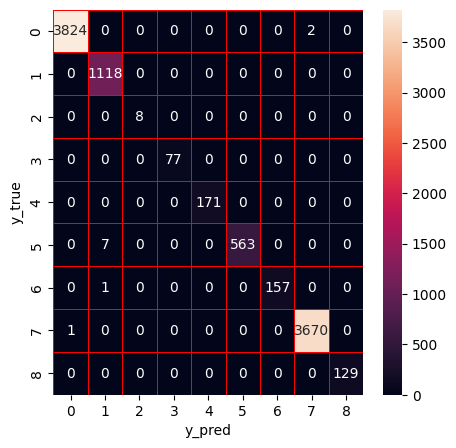

CPU times: total: 5.81 s
Wall time: 5.81 s


In [22]:
%%time
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Extra Trees training and prediction with 3-fold cross-validation
et = ExtraTreesClassifier(random_state=0)
et_scores = cross_val_score(et, X_train, y_train, cv=3)
# calculate the training time
start = time.time()
et.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = et.predict(X_test)
end = time.time()
print('Prediction time: ', (end - start) / len(X_test) * 1000, 'ms')
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', et_scores)
print('Mean of Cross-Validation scores: ', np.mean(et_scores))
# Evaluation metrics
et_score = et.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of ET: ' + str(et_score))
print('Precision of ET: ' + str(precision))
print('Recall of ET: ' + str(recall))
print('F1-score of ET: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### XGBoost

Training time:  5.44543981552124
Prediction time per sample:  0.0008201765778817629
Cross-Validation scores:  [0.99861218 0.99838075 0.99899761]
Mean of Cross-Validation scores:  0.9986635152496476
Accuracy of XGBoost: 0.998766447368421
Precision of XGBoost: 0.9987674717418612
Recall of XGBoost: 0.998766447368421
F1-score of XGBoost: 0.9987655064993063
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       0.99      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      

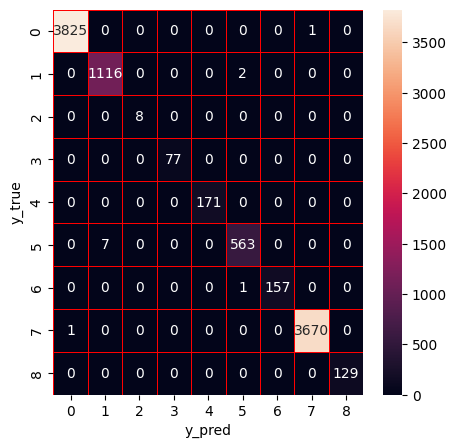

In [23]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# XGBoost training and prediction with 3-fold cross-validation
xg = xgb.XGBClassifier(random_state=0)
xg_scores = cross_val_score(xg, X_train, y_train, cv=3)

# calculate the training time
start = time.time()
xg.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = xg.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)


y_true = y_test

# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', xg_scores)
print('Mean of Cross-Validation scores: ', np.mean(xg_scores))

# Evaluation metrics
xg_score = xg.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of XGBoost: ' + str(xg_score))
print('Precision of XGBoost: ' + str(precision))
print('Recall of XGBoost: ' + str(recall))
print('F1-score of XGBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### LightGBM

Training time:  1.5917439460754395
Prediction time per sample:  0.004203328372616518
Cross-Validation scores:  [0.99830378 0.99861207 0.9989205 ]
Mean of Cross-Validation scores:  0.9986121185447875
Accuracy of LightGBM: 0.9988692434210527
Precision of LightGBM: 0.9988703578477212
Recall of LightGBM: 0.9988692434210527
F1-score of LightGBM: 0.9988684826869288
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      0.99      0.99        77
           4       1.00      1.00      1.00       171
           5       0.99      0.99      0.99       570
           6       0.99      0.99      0.99       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.0

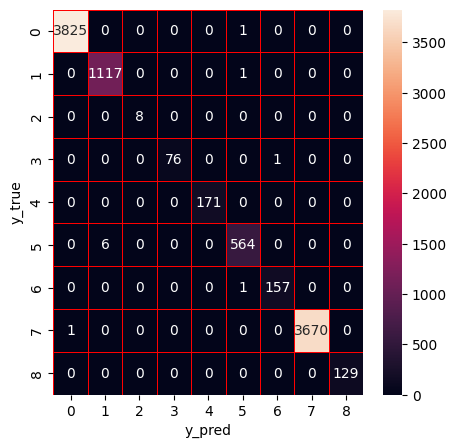

In [24]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# LightGBM training and prediction with 3-fold cross-validation
lgbm = lgb.LGBMClassifier(random_state=0)
lgbm_scores = cross_val_score(lgbm, X_train, y_train, cv=3)

# calculate the training time
start = time.time()
lgbm.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = lgbm.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)



y_true = y_test

# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', lgbm_scores)
print('Mean of Cross-Validation scores: ', np.mean(lgbm_scores))

# Evaluation metrics
lgbm_score = lgbm.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of LightGBM: ' + str(lgbm_score))
print('Precision of LightGBM: ' + str(precision))
print('Recall of LightGBM: ' + str(recall))
print('F1-score of LightGBM: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


#### Catboost

Training time:  26.32460045814514
Prediction time per sample:  0.008919423348025271
Cross-Validation scores:  [0.99892059 0.99838075 0.99876629]
Mean of Cross-Validation scores:  0.9986892096387291
Accuracy of CatBoost: 0.9984580592105263
Precision of CatBoost: 0.9984634333522431
Recall of CatBoost: 0.9984580592105263
F1-score of CatBoost: 0.9984568172129848
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       0.99      1.00      0.99        77
           4       1.00      0.99      1.00       171
           5       0.99      0.98      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       0.99      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00

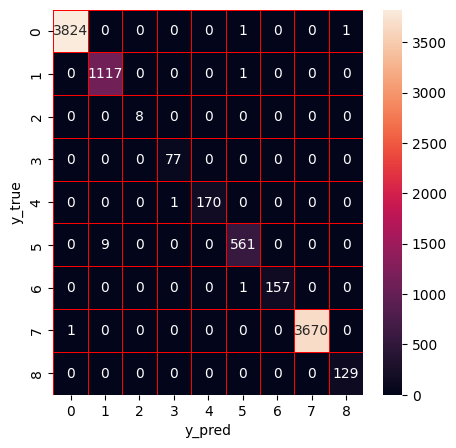

In [25]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# CatBoost training and prediction with 3-fold cross-validation
cat = CatBoostClassifier(random_state=0, verbose=False)
cat_scores = cross_val_score(cat, X_train, y_train, cv=3)


# calculate the training time
start = time.time()
cat.fit(X_train, y_train)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = cat.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)


# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', cat_scores)
print('Mean of Cross-Validation scores: ', np.mean(cat_scores))

# Evaluation metrics
cat_score = cat.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of CatBoost: ' + str(cat_score))
print('Precision of CatBoost: ' + str(precision))
print('Recall of CatBoost: ' + str(recall))
print('F1-score of CatBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


In [26]:
# record the results
dt_train=dt.predict(X_train)
dt_test=dt.predict(X_test)
dt_prob_train=dt.predict_proba(X_train)
dt_prob_test=dt.predict_proba(X_test)

rf_train=rf.predict(X_train)
rf_test=rf.predict(X_test)
rf_prob_train=rf.predict_proba(X_train)
rf_prob_test=rf.predict_proba(X_test)

et_train=et.predict(X_train)
et_test=et.predict(X_test)
et_prob_train=et.predict_proba(X_train)
et_prob_test=et.predict_proba(X_test)

xg_train=xg.predict(X_train)
xg_test=xg.predict(X_test)
xg_prob_train=xg.predict_proba(X_train)
xg_prob_test=xg.predict_proba(X_test)

lgbm_train=lgbm.predict(X_train)
lgbm_test=lgbm.predict(X_test)
lgbm_prob_train=lgbm.predict_proba(X_train)
lgbm_prob_test=lgbm.predict_proba(X_test)

cat_train=cat.predict(X_train)
cat_test=cat.predict(X_test)
cat_prob_train=cat.predict_proba(X_train)
cat_prob_test=cat.predict_proba(X_test)


# Save Phase 1 Base Models
import os, joblib
model_dir = '/content/drive/My Drive/Colab Notebooks/Assignment/Data/models_dataset2/'
os.makedirs(model_dir + 'phase1_initial_base_models', exist_ok=True)
joblib.dump(dt, model_dir + 'phase1_initial_base_models/dt_model.joblib')
joblib.dump(rf, model_dir + 'phase1_initial_base_models/rf_model.joblib')
joblib.dump(et, model_dir + 'phase1_initial_base_models/et_model.joblib')
joblib.dump(xg, model_dir + 'phase1_initial_base_models/xg_model.joblib')
joblib.dump(lgbm, model_dir + 'phase1_initial_base_models/lgbm_model.joblib')
joblib.dump(cat, model_dir + 'phase1_initial_base_models/cat_model.joblib')
print('Phase 1: Initial Base Models saved successfully to Google Drive!')

## Model selection

In [27]:
# Calculate the performance of each base model (e.g., accuracy)
base_model_performance = {
    'dt': np.mean(dt_scores),
    'rf': np.mean(rf_scores),
    'et': np.mean(et_scores),
    'xg': np.mean(xg_scores),
    'lgbm': np.mean(lgbm_scores),
    'cat': np.mean(cat_scores)

}

# Rank the base models based on their performance
ranked_models = sorted(base_model_performance, key=base_model_performance.get, reverse=True)

# Select the top-3 performing base models
top_3_models = ranked_models[:3]



In [28]:
top_3_models

['rf', 'cat', 'xg']

## Model Ensemble

In [29]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
lgbm_train=lgbm_train.reshape(-1, 1)
cat_train=cat_train.reshape(-1, 1)


dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)
lgbm_test=lgbm_test.reshape(-1, 1)
cat_test=cat_test.reshape(-1, 1)

Training time of Stacking: 0.8985965251922607
Testing time of Stacking: 0.0005125950433705983
Accuracy of Stacking: 0.9985608552631579
Precision of Stacking: 0.998565270332061
Recall of Stacking: 0.9985608552631579
F1-score of Stacking: 0.9985596551122141
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      0.99      1.00       171
           5       1.00      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1.00      1.00      1.00      9728



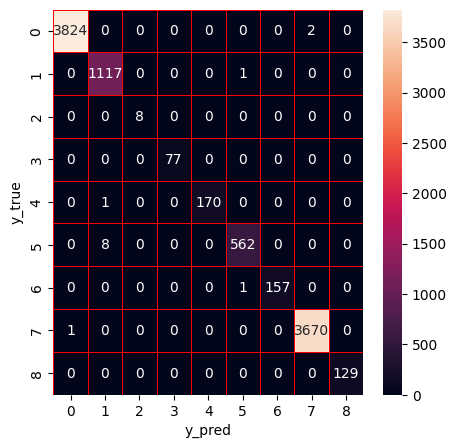

In [30]:
# Ensemble method 1: traditional stacking

# Get the predictions of the top-3 models
top_3_train_predictions = [globals()[model.lower() + '_train'] for model in top_3_models]
top_3_test_predictions = [globals()[model.lower() + '_test'] for model in top_3_models]

# Stack the predictions of the top-3 models
x_train = np.concatenate(top_3_train_predictions, axis=1)
x_test = np.concatenate(top_3_test_predictions, axis=1)

# Train and evaluate the stacking model
# calcualte the traning time
start_time = time.time()
#stk = lgb.LGBMClassifier().fit(x_train, y_train)
stk =  xgb.XGBClassifier(random_state=0).fit(x_train, y_train)
end_time = time.time()
stk_time = end_time - start_time
print('Training time of Stacking: '+ str(stk_time))

# calcualte the testing time per sample in milliseconds
start_time = time.time()
y_predict=stk.predict(x_test)
end_time = time.time()
stk_time = (end_time - start_time)/len(x_test)*1000
print('Testing time of Stacking: '+ str(stk_time))

y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


Training time of Stacking: 2.1143460273742676
Testing time of Stacking: 0.0006150405265783009
Accuracy of Stacking: 0.9991776315789473
Precision of Stacking: 0.9991778500646348
Recall of Stacking: 0.9991776315789473
F1-score of Stacking: 0.9991774273565044
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      1.00       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1.00      1.00      1.00      9728



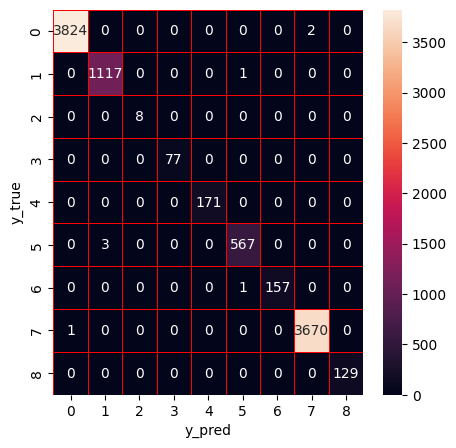

In [31]:
# Ensemble method 2: confidence-based stacking

# Get the prediction probabilities of the top-3 models
top_3_train_proba = [globals()[model.lower() + '_prob_train'] for model in top_3_models]
top_3_test_proba = [globals()[model.lower() + '_prob_test'] for model in top_3_models]

# Stack the predictions and prediction probabilities of the top-3 models
x_train = np.concatenate(top_3_train_proba, axis=1)
x_test = np.concatenate(top_3_test_proba, axis=1)

# Train and evaluate the stacking model
# calcualte the traning time
start_time = time.time()
#stk = lgb.LGBMClassifier().fit(x_train, y_train)
stk =  xgb.XGBClassifier(random_state=0).fit(x_train, y_train)
end_time = time.time()
stk_time = end_time - start_time
print('Training time of Stacking: '+ str(stk_time))

# calcualte the testing time per sample in milliseconds
start_time = time.time()
y_predict=stk.predict(x_test)
end_time = time.time()
stk_time = (end_time - start_time)/len(x_test)*1000
print('Testing time of Stacking: '+ str(stk_time))

y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

Training time of Stacking: 2.1871519088745117
Testing time of Stacking: 0.0004101495601628956
Accuracy of Stacking: 0.9991776315789473
Precision of Stacking: 0.9991778500646348
Recall of Stacking: 0.9991776315789473
F1-score of Stacking: 0.9991774273565044
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      1.00       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1.00      1.00      1.00      9728



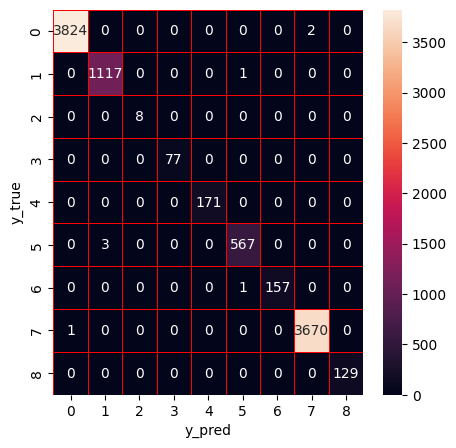

In [32]:
# Ensemble method 3: hybrid stacking

# Get the predictions and prediction probabilities of the top-3 models
top_3_train_predictions = [globals()[model.lower() + '_train'] for model in top_3_models]
top_3_test_predictions = [globals()[model.lower() + '_test'] for model in top_3_models]

top_3_train_proba = [globals()[model.lower() + '_prob_train'] for model in top_3_models]
top_3_test_proba = [globals()[model.lower() + '_prob_test'] for model in top_3_models]

# Combine the predictions and prediction probabilities of the top-3 models
x_train = np.concatenate(top_3_train_predictions + top_3_train_proba, axis=1)
x_test = np.concatenate(top_3_test_predictions + top_3_test_proba, axis=1)

# Train and evaluate the stacking model
# calcualte the traning time
start_time = time.time()
#stk = lgb.LGBMClassifier().fit(x_train, y_train)
stk =  xgb.XGBClassifier(random_state=0).fit(x_train, y_train)
end_time = time.time()
stk_time = end_time - start_time
print('Training time of Stacking: '+ str(stk_time))

# calcualte the testing time per sample in milliseconds
start_time = time.time()
y_predict=stk.predict(x_test)
end_time = time.time()
stk_time = (end_time - start_time)/len(x_test)*1000
print('Testing time of Stacking: '+ str(stk_time))

y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

# Save Phase 1 Stacking Model
os.makedirs(model_dir + 'phase1_initial_stacking', exist_ok=True)
joblib.dump(stk, model_dir + 'phase1_initial_stacking/stk_initial.joblib')
print('Phase 1: Initial Stacking Model saved successfully to Google Drive!')

## Automated Feature Selection

In [41]:
# Save the feature importance lists generated by base ML algorithms
dt_feature = dt.feature_importances_
rf_feature = rf.feature_importances_
et_feature = et.feature_importances_
xg_feature = xg.feature_importances_
lgbm_feature = lgbm.feature_importances_
cat_feature = cat.feature_importances_

In [42]:
lgbm_feature = lgbm_feature/sum(lgbm_feature)
cat_feature = cat_feature/sum(cat_feature)

In [43]:
# Get the feature importances of the top-3 models
top_3_importances = [globals()[model.lower() + '_feature'] for model in top_3_models]

# Calculate the average importance of each feature
avg_feature = np.mean(top_3_importances, axis=0)

feature=(df.drop(['Label'],axis=1)).columns.values
print ("Features sorted by their score:")
print (sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True))

f_list = sorted(zip(map(lambda x: round(x, 4), avg_feature), feature), reverse=True)


Features sorted by their score:
[(0.1799, 'Seq'), (0.1329, 'sMeanPktSz'), (0.0798, 'sTtl'), (0.0755, 'AckDat'), (0.0647, 'dDSb'), (0.0571, 'Offset'), (0.0497, 'SrcWin'), (0.0363, 'State'), (0.0335, 'SrcTCPBase'), (0.0317, 'Proto'), (0.0298, 'TcpRtt'), (0.0281, 'TotBytes'), (0.0244, 'sHops'), (0.0209, 'Loss'), (0.0208, 'SrcBytes'), (0.0176, 'SynAck'), (0.0152, 'DstWin'), (0.0124, 'dTtl'), (0.0124, 'Cause'), (0.0103, 'dMeanPktSz'), (0.0067, 'dHops'), (0.0065, 'SrcRate'), (0.0061, 'DstTCPBase'), (0.0049, 'sVid'), (0.0043, 'Sum'), (0.0039, 'Dur'), (0.0036, 'DstBytes'), (0.0034, 'SrcPkts'), (0.0033, 'Mean'), (0.0033, 'DstPkts'), (0.0031, 'sTos'), (0.003, 'RunTime'), (0.0028, 'pLoss'), (0.0027, 'Min'), (0.0025, 'Max'), (0.0018, 'Rate'), (0.0017, 'TotPkts'), (0.0015, 'Load'), (0.0008, 'SrcLoad'), (0.0003, 'SrcLoss'), (0.0003, 'DstRate'), (0.0003, 'DstLoad'), (0.0, 'sDSb'), (0.0, 'dVid'), (0.0, 'dTos'), (0.0, 'SrcGap'), (0.0, 'DstLoss'), (0.0, 'DstGap')]


In [44]:
# Select the important features from top-importance to bottom-importance until the accumulated importance reaches 0.9 (out of 1)
Sum = 0
fs = []
for i in range(0, len(f_list)):
    Sum = Sum + f_list[i][0]
    fs.append(f_list[i][1])
    if Sum>=0.9:
        break        

In [45]:
# regenerate the training and test sets with the selected features

X_fs = df[fs].values
X_train, X_test, y_train, y_test = train_test_split(X_fs,y, train_size = 0.8, test_size = 0.2, random_state = 0,stratify = y)

In [46]:
X_train.shape

(38908, 18)

In [60]:
# save the dataset with the selected features
df_fs = pd.DataFrame(X_fs, columns=fs)
df_fs['Label'] = y
df_fs.to_csv('/content/drive/My Drive/Colab Notebooks/Assignment/Data/5G-NIDD_0.04_fs.csv', index=False)

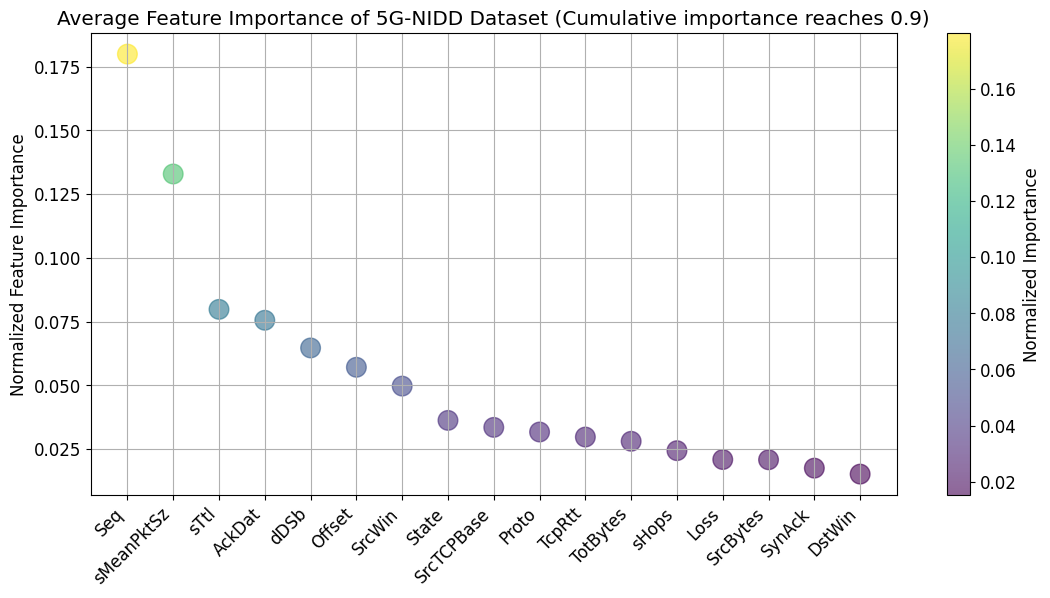

In [47]:
# Plot the feature importance of the top-3 models
plt.rcParams.update({'font.size': 12})

# Create a DataFrame for easier plotting
features = pd.DataFrame({
    'Feature': df.drop(['Label'],axis=1).columns,
    'Importance': avg_feature
})

# Sort features by importance
features = features.sort_values(by='Importance', ascending=False)

# Calculate cumulative importance and filter features
features['Cumulative'] = features['Importance'].cumsum()
filtered_features = features[features['Cumulative'] <= 0.9]

# Plotting
plt.figure(figsize=(13, 6))
scatter = plt.scatter(x='Feature', y='Importance', s=200, c='Importance', cmap='viridis', alpha=0.6, data=filtered_features)
plt.colorbar(scatter, label='Normalized Importance')
plt.xticks(rotation=45, ha='right')
plt.title('Average Feature Importance of 5G-NIDD Dataset (Cumulative importance reaches 0.9)')
plt.ylabel('Normalized Feature Importance')
plt.grid(True)
plt.show()

### Data Balancing by Proposed TVAE-based Method

In [61]:
pd.Series(y_train).value_counts()

Label
0    15304
7    14680
1     4469
5     2278
4      685
6      632
8      518
3      309
2       33
Name: count, dtype: int64

In [62]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_csv(filepath='/content/drive/My Drive/Colab Notebooks/Assignment/Data/5G-NIDD_0.04_fs.csv')


In [64]:
# Ensure all columns in df are numeric before splitting
from sklearn.preprocessing import LabelEncoder
for col in df.columns:
    if df[col].dtype == 'object' or df[col].dtype.name == 'category':
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))

training_set, test_set = train_test_split(df, test_size = 0.2, random_state = 0, stratify = df['Label'])
X_train = training_set[fs].values.astype(np.float64)
y_train = training_set['Label'].values
X_test = test_set[fs].values.astype(np.float64)
y_test = test_set['Label'].values


In [65]:
training_set['Label'].value_counts()

Label
0    15304
7    14680
1     4469
5     2278
4      685
6      632
8      518
3      309
2       33
Name: count, dtype: int64

In [67]:
from sdv.single_table import TVAESynthesizer
# Identify the average number of samples per class
average_samples = pd.Series(y_train).value_counts().mean()

# Identify minority classes with less than half the average number of samples
minority_classes = pd.Series(y_train).value_counts()
minority_classes = minority_classes[minority_classes < average_samples / 2].index.tolist()

# Prepare an empty DataFrame to collect synthetic data
synthetic_data = pd.DataFrame()

In [68]:
# Generating synthetic samples for each minority class using TVAE
for cls in minority_classes:
    cls_samples = X_train[y_train == cls]
    num_samples_needed = int(average_samples - len(cls_samples))
    
    # Initialize the TVAE model with detected metadata
    tvaegan = TVAESynthesizer(metadata=metadata)
    
    # Convert to DataFrame with Label for TVAE fitting
    cls_df = pd.DataFrame(cls_samples, columns=fs)
    cls_df['Label'] = y_train[y_train == cls]
    tvaegan.fit(cls_df)
    
    # Generate synthetic instances to match the average class sample size
    new_samples = tvaegan.sample(num_samples_needed)
    
    # Append the new synthetic instances to the synthetic data list
    synthetic_data = pd.concat([synthetic_data, new_samples], ignore_index=True)


# Save Phase 2 TVAE Synthesizer Model
os.makedirs(model_dir + 'phase2_tvae_synthesizer', exist_ok=True)
tvaegan.save(model_dir + 'phase2_tvae_synthesizer/tvae_synthesizer.pkl')
print('Phase 2: TVAE Data Balancing Synthesizer saved successfully to Google Drive!')


In [69]:
# Concatenate the original and synthetic data to form a balanced dataset
X_tr_df = pd.DataFrame(X_train, columns=fs)
X_tr_df['Label'] = y_train
balanced_data = pd.concat([X_tr_df, synthetic_data], ignore_index=True)

# Display the new distribution of labels in the balanced dataset
print(balanced_data['Label'].value_counts())

# Ensure all features in balanced_data are numeric float64
for col in balanced_data.columns:
    if col != 'Label' and (balanced_data[col].dtype == 'object' or balanced_data[col].dtype.name == 'category'):
        balanced_data[col] = LabelEncoder().fit_transform(balanced_data[col].astype(str))

# Prepare the balanced dataset for model training
X_train_balanced = balanced_data.drop(['Label'], axis=1).values.astype(np.float64)
y_train_balanced = balanced_data['Label'].values


Label
0    15304
7    14680
1     4469
3     4323
8     4323
6     4323
4     4323
2     4323
5     2278
Name: count, dtype: int64


## Machine learning model training

### Training six base learners: 
decision tree, random forest, extra trees, XGBoost, LightGBM, and CatBoost


### Cross-validation

### DT

Training time:  0.17552900314331055
Prediction time per sample:  0.00010276409356217635
Cross-Validation scores:  [0.98652887 0.99866317 0.99876594]
Mean of Cross-Validation scores:  0.994652660221433
Accuracy of DT: 0.9984580592105263
Precision of DT: 0.998471419566769
Recall of DT: 0.9984580592105263
F1-score of DT: 0.998460520848183
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       0.89      1.00      0.94         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       0.99      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       0.99      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       0.99      1.00      0.99      9728
weighted avg

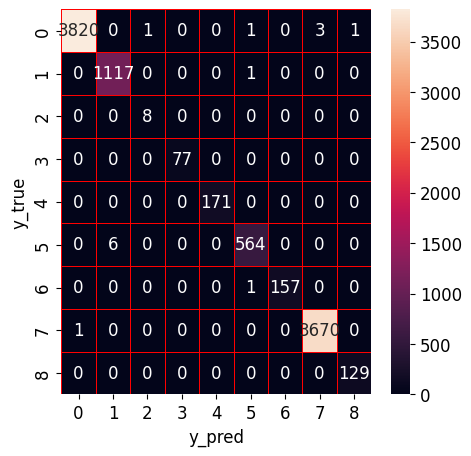

CPU times: total: 922 ms
Wall time: 920 ms


In [73]:
%%time
X_train_balanced = np.asarray(X_train_balanced, dtype=np.float64)
y_train_balanced = np.asarray(y_train_balanced)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
# Decision tree training and prediction with 3-fold cross-validation
dt = DecisionTreeClassifier(random_state=0)
dt_scores = cross_val_score(dt, X_train_balanced, y_train_balanced, cv=3)
# calculate the training time
start = time.time()
dt.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = dt.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test)*1000)
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', dt_scores)
print('Mean of Cross-Validation scores: ', np.mean(dt_scores))
# Evaluation metrics
dt_score = dt.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of DT: ' + str(dt_score))
print('Precision of DT: ' + str(precision))
print('Recall of DT: ' + str(recall))
print('F1-score of DT: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [00:09<00:00,  2.06trial/s, best loss: -0.9978404856695136]
Decision Tree: Hyperopt estimated optimum {'criterion': 'entropy', 'max_depth': 48, 'min_samples_leaf': 8, 'min_samples_split': 9}
Accuracy of DT: 0.9981496710526315
Precision of DT: 0.9981499219017778
Recall of DT: 0.9981496710526315
F1-score of DT: 0.9981482236008399
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       0.99      1.00      0.99        77
           4       0.99      0.99      0.99       171
           5       0.99      0.98      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      97

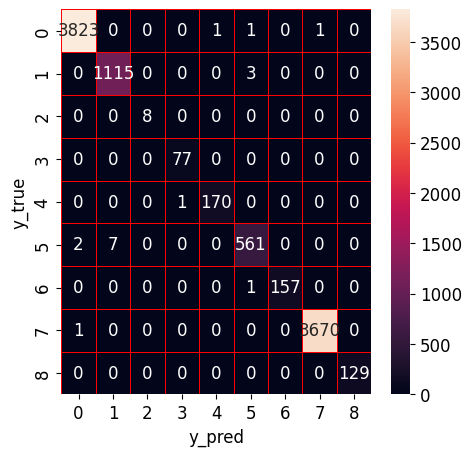

In [75]:
# Hyperparameter Optimization using BO-TPE

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'max_depth': int(params['max_depth']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'criterion': ['gini', 'entropy'][int(params['criterion'])]
    }
    clf = DecisionTreeClassifier(random_state=0, **params)
    score = cross_val_score(clf, X_train_balanced, y_train_balanced, scoring='accuracy', cv=StratifiedKFold(n_splits=3)).mean()

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'max_depth': hp.quniform('max_depth', 1, 50, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 11, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 11, 1),
    'criterion': hp.choice('criterion', [0, 1])  # 0 for 'gini', 1 for 'entropy'
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['max_depth'] = int(best['max_depth'])
best['min_samples_split'] = int(best['min_samples_split'])
best['min_samples_leaf'] = int(best['min_samples_leaf'])
best['criterion'] = ['gini', 'entropy'][int(best['criterion'])]

print("Decision Tree: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
dt = DecisionTreeClassifier(random_state=0, **best)
dt.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = dt.predict(X_test)
y_true = y_test

# Evaluation metrics
dt_score = dt.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of DT: ' + str(dt_score))
print('Precision of DT: ' + str(precision))
print('Recall of DT: ' + str(recall))
print('F1-score of DT: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### RF

Training time:  4.326404094696045
Prediction time:  0.0068690676830316846 ms
Cross-Validation scores:  [0.99691501 0.99922875 0.99938297]
Mean of Cross-Validation scores:  0.9985089101919545
Accuracy of RF: 0.9988692434210527
Precision of RF: 0.9988699921444715
Recall of RF: 0.9988692434210527
F1-score of RF: 0.9988688755514655
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       0.99      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1

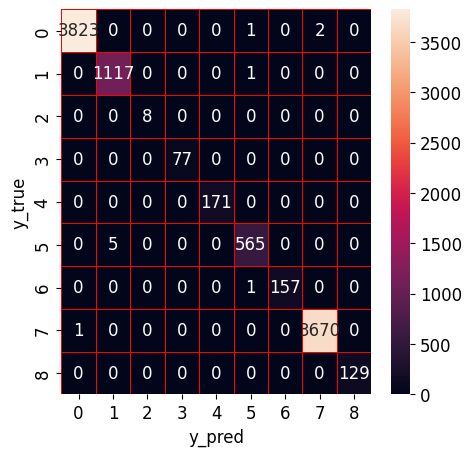

CPU times: total: 13.8 s
Wall time: 13.8 s


In [76]:
%%time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Random Forest training and prediction with 3-fold cross-validation
rf = RandomForestClassifier(random_state=0)
rf_scores = cross_val_score(rf, X_train_balanced, y_train_balanced, cv=3)
# calculate the training time
start = time.time()
rf.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = rf.predict(X_test)
end = time.time()
print('Prediction time: ', (end - start) / len(y_predict) * 1000, 'ms')
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', rf_scores)
print('Mean of Cross-Validation scores: ', np.mean(rf_scores))
# Evaluation metrics
rf_score = rf.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of RF: ' + str(rf_score))
print('Precision of RF: ' + str(precision))
print('Recall of RF: ' + str(recall))
print('F1-score of RF: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


In [77]:
# Hyperparameter Optimization using BO-TPE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'criterion': ['gini', 'entropy'][int(params['criterion'])]
    }
    clf = RandomForestClassifier(random_state=0, **params)
    score = cross_val_score(clf, X_train_balanced, y_train_balanced, scoring='accuracy', cv=StratifiedKFold(n_splits=3)).mean()

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 200, 1),
    'max_depth': hp.quniform('max_depth', 5, 50, 1),
    "max_features":hp.quniform('max_features', 1, 40, 1),
    "min_samples_split":hp.quniform('min_samples_split',2,11,1),
    "min_samples_leaf":hp.quniform('min_samples_leaf',1,11,1),
    'criterion': hp.choice('criterion', [0, 1])  # 0 for 'gini', 1 for 'entropy'
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['max_features'] = int(best['max_features'])
best['min_samples_split'] = int(best['min_samples_split'])
best['min_samples_leaf'] = int(best['min_samples_leaf'])
best['criterion'] = ['gini', 'entropy'][int(best['criterion'])]

print("Random Forest: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
rf = RandomForestClassifier(random_state=0, **best)
rf.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = rf.predict(X_test)
y_true = y_test

# Evaluation metrics
rf_score = rf.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of RF: ' + str(rf_score))
print('Precision of RF: ' + str(precision))
print('Recall of RF: ' + str(recall))
print('F1-score of RF: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [07:43<00:00, 23.19s/trial, best loss: -0.9983546579723459]
Random Forest: Hyperopt estimated optimum {'criterion': 'entropy', 'max_depth': 18, 'max_features': 4, 'min_samples_leaf': 9, 'min_samples_split': 5, 'n_estimators': 127}
Accuracy of RF: 0.9988692434210527
Precision of RF: 0.9988713230716716
Recall of RF: 0.9988692434210527
F1-score of RF: 0.9988690275123507
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       0.99      1.00      0.99        77
           4       1.00      0.99      1.00       171
           5       0.99      0.99      0.99       570
           6       0.99      0.99      0.99       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro av

### ET

Training time:  1.4132225513458252
Prediction time:  0.009534145264249099 ms
Cross-Validation scores:  [0.99856034 0.9990745  0.99938297]
Mean of Cross-Validation scores:  0.9990059366029097
Accuracy of ET: 0.9991776315789473
Precision of ET: 0.9991785826962032
Recall of ET: 0.9991776315789473
F1-score of ET: 0.9991771583104744
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      1.00       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1

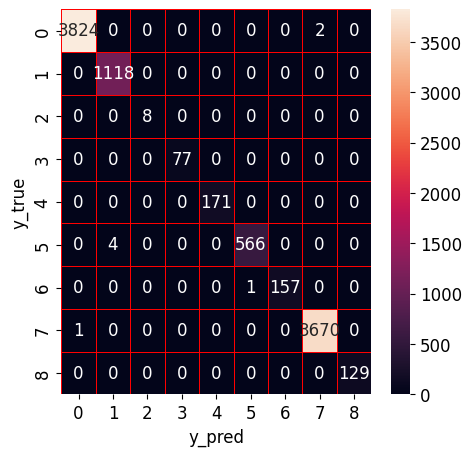

CPU times: total: 5.28 s
Wall time: 5.29 s


In [78]:
%%time
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Extra Trees training and prediction with 3-fold cross-validation
et = ExtraTreesClassifier(random_state=0)
et_scores = cross_val_score(et, X_train_balanced, y_train_balanced, cv=3)
# calculate the training time
start = time.time()
et.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)
# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = et.predict(X_test)
end = time.time()
print('Prediction time: ', (end - start) / len(X_test) * 1000, 'ms')
y_true = y_test
# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', et_scores)
print('Mean of Cross-Validation scores: ', np.mean(et_scores))
# Evaluation metrics
et_score = et.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')
# Print results
print('Accuracy of ET: ' + str(et_score))
print('Precision of ET: ' + str(precision))
print('Recall of ET: ' + str(recall))
print('F1-score of ET: ' + str(fscore))
print(classification_report(y_true, y_predict))
# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [01:32<00:00,  4.65s/trial, best loss: -0.9991773259017455]
Extra Trees: Hyperopt estimated optimum {'criterion': 'entropy', 'max_depth': 47, 'max_features': 15, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 141}
Accuracy of ET: 0.9993832236842105
Precision of ET: 0.9993834399162879
Recall of ET: 0.9993832236842105
F1-score of ET: 0.9993830183309974
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      1.00       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro av

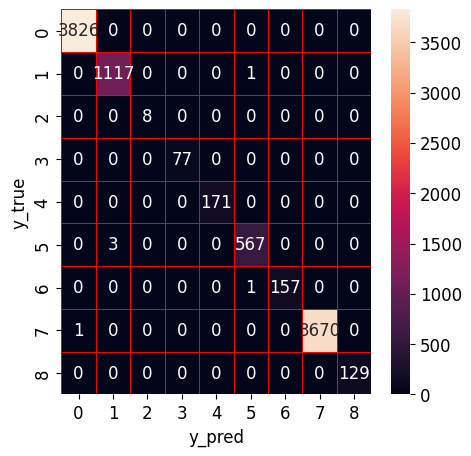

In [79]:
# Hyperparameter Optimization using BO-TPE

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'max_features': int(params['max_features']),
        'min_samples_split': int(params['min_samples_split']),
        'min_samples_leaf': int(params['min_samples_leaf']),
        'criterion': ['gini', 'entropy'][int(params['criterion'])]
    }
    clf = ExtraTreesClassifier(random_state=0, **params)
    score = cross_val_score(clf, X_train_balanced, y_train_balanced, scoring='accuracy', cv=StratifiedKFold(n_splits=3)).mean()

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 200, 1),
    'max_depth': hp.quniform('max_depth', 1, 50, 1),
    'max_features': hp.quniform('max_features', 1, 20, 1),
    'min_samples_split': hp.quniform('min_samples_split', 2, 11, 1),
    'min_samples_leaf': hp.quniform('min_samples_leaf', 1, 11, 1),
    'criterion': hp.choice('criterion', [0, 1])  # 0 for 'gini', 1 for 'entropy'
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['max_features'] = int(best['max_features'])
best['min_samples_split'] = int(best['min_samples_split'])
best['min_samples_leaf'] = int(best['min_samples_leaf'])
best['criterion'] = ['gini', 'entropy'][int(best['criterion'])]

print("Extra Trees: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
et = ExtraTreesClassifier(random_state=0, **best)
et.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = et.predict(X_test)
y_true = y_test

# Evaluation metrics
et_score = et.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of ET: ' + str(et_score))
print('Precision of ET: ' + str(precision))
print('Recall of ET: ' + str(recall))
print('F1-score of ET: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### XGBoost

Training time:  6.086725473403931
Prediction time per sample:  0.0009226710780670768
Cross-Validation scores:  [0.99331585 0.99912592 0.99938297]
Mean of Cross-Validation scores:  0.9972749135854452
Accuracy of XGBoost: 0.998766447368421
Precision of XGBoost: 0.9987671715079545
Recall of XGBoost: 0.998766447368421
F1-score of XGBoost: 0.9987660949996434
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       0.99      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00     

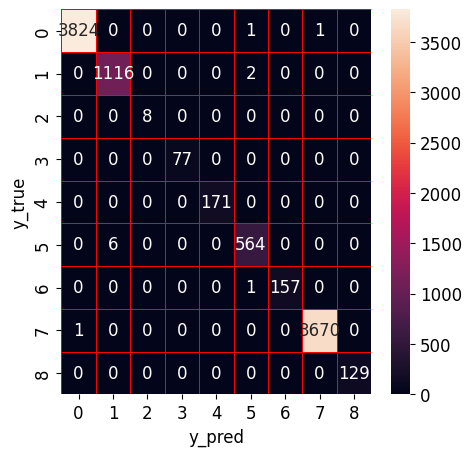

In [80]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# XGBoost training and prediction with 3-fold cross-validation
xg = xgb.XGBClassifier(random_state=0)
xg_scores = cross_val_score(xg, X_train_balanced, y_train_balanced, cv=3)

# calculate the training time
start = time.time()
xg.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = xg.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)


y_true = y_test

# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', xg_scores)
print('Mean of Cross-Validation scores: ', np.mean(xg_scores))

# Evaluation metrics
xg_score = xg.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of XGBoost: ' + str(xg_score))
print('Precision of XGBoost: ' + str(precision))
print('Recall of XGBoost: ' + str(recall))
print('F1-score of XGBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [01:08<00:00,  3.40s/trial, best loss: -0.9989720394736842]
XGBoost: Hyperopt estimated optimum {'learning_rate': 1.0327545373238691, 'max_depth': 100, 'n_estimators': 85}
Accuracy of XGBoost: 0.9989720394736842
Precision of XGBoost: 0.9989735227718259
Recall of XGBoost: 0.9989720394736842
F1-score of XGBoost: 0.9989721474656937
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       0.99      1.00      0.99        77
           4       1.00      1.00      1.00       171
           5       0.99      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9

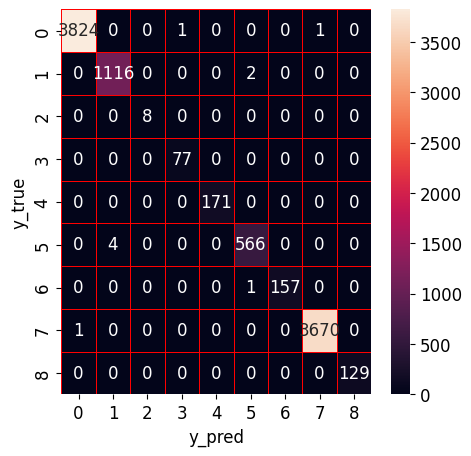

In [81]:
# Hyperparameter Optimization using BO-TPE

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': abs(float(params['learning_rate']))
    }
    clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=0, **params)
    clf.fit(X_train_balanced, y_train_balanced)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 100, 5),
    'max_depth': hp.quniform('max_depth', 4, 100, 1),
    'learning_rate': hp.normal('learning_rate', 0.01, 0.9)
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['learning_rate'] = abs(float(best['learning_rate']))

print("XGBoost: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
xg = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=0, **best)
xg.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = xg.predict(X_test)
y_true = y_test

# Evaluation metrics
xg_score = xg.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of XGBoost: ' + str(xg_score))
print('Precision of XGBoost: ' + str(precision))
print('Recall of XGBoost: ' + str(recall))
print('F1-score of XGBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### LightGBM

Training time:  1.5680267810821533
Prediction time per sample:  0.004614213187443583
Cross-Validation scores:  [0.99326444 0.9990745  0.99948581]
Mean of Cross-Validation scores:  0.9972749153479752
Accuracy of LightGBM: 0.9988692434210527
Precision of LightGBM: 0.9988716488710466
Recall of LightGBM: 0.9988692434210527
F1-score of LightGBM: 0.9988689669001192
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       0.99      1.00      0.99        77
           4       1.00      1.00      1.00       171
           5       0.99      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.0

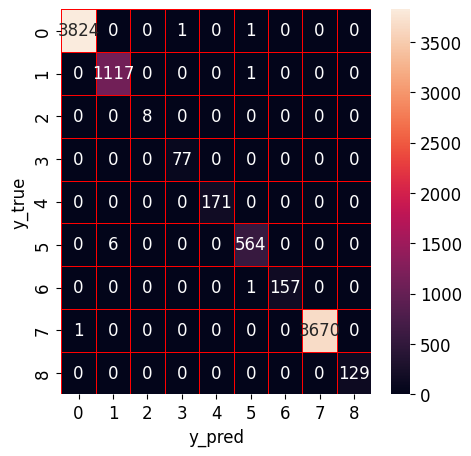

In [82]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# LightGBM training and prediction with 3-fold cross-validation
lgbm = lgb.LGBMClassifier(random_state=0)
lgbm_scores = cross_val_score(lgbm, X_train_balanced, y_train_balanced, cv=3)

# calculate the training time
start = time.time()
lgbm.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = lgbm.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)



y_true = y_test

# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', lgbm_scores)
print('Mean of Cross-Validation scores: ', np.mean(lgbm_scores))

# Evaluation metrics
lgbm_score = lgbm.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of LightGBM: ' + str(lgbm_score))
print('Precision of LightGBM: ' + str(precision))
print('Recall of LightGBM: ' + str(recall))
print('F1-score of LightGBM: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 20/20 [00:22<00:00,  1.11s/trial, best loss: -0.9991776315789473]
LightGBM: Hyperopt estimated optimum {'learning_rate': 0.35892790441669187, 'max_depth': 78, 'min_child_samples': 65, 'n_estimators': 45, 'num_leaves': 110}
Accuracy of LightGBM: 0.9991776315789473
Precision of LightGBM: 0.9991781900000193
Recall of LightGBM: 0.9991776315789473
F1-score of LightGBM: 0.9991774898670388
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       1.00      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       0.99      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
 

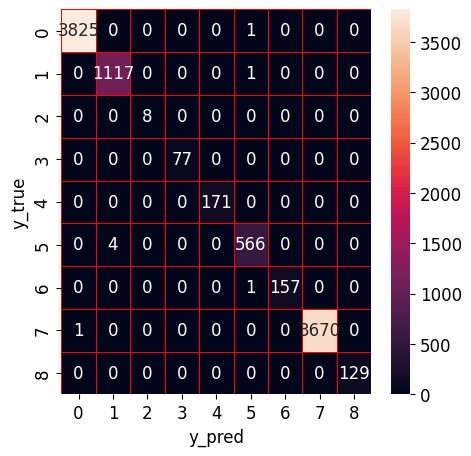

In [83]:
# Hyperparameter Optimization using BO-TPE

import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'n_estimators': int(params['n_estimators']),
        'max_depth': int(params['max_depth']),
        'learning_rate': abs(float(params['learning_rate'])),
        'num_leaves': int(params['num_leaves']),
        'min_child_samples': int(params['min_child_samples'])
    }
    clf = lgb.LGBMClassifier(random_state=0, **params)
    clf.fit(X_train_balanced, y_train_balanced)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'n_estimators': hp.quniform('n_estimators', 10, 100, 5),
    'max_depth': hp.quniform('max_depth', 4, 100, 1),
    'learning_rate': hp.normal('learning_rate', 0.01, 0.9),
    'num_leaves': hp.quniform('num_leaves', 10, 200, 5),
    'min_child_samples': hp.quniform('min_child_samples', 5, 100, 5)
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=20)

# Convert the returned hyperparameters to their original types
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['learning_rate'] = abs(float(best['learning_rate']))
best['num_leaves'] = int(best['num_leaves'])
best['min_child_samples'] = int(best['min_child_samples'])

print("LightGBM: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
lgbm = lgb.LGBMClassifier(random_state=0, **best)
lgbm.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = lgbm.predict(X_test)
y_true = y_test

# Evaluation metrics
lgbm_score = lgbm.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of LightGBM: ' + str(lgbm_score))
print('Precision of LightGBM: ' + str(precision))
print('Recall of LightGBM: ' + str(recall))
print('F1-score of LightGBM: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


### CatBoost

Training time:  25.10241961479187
Prediction time per sample:  0.0011279296718145673
Cross-Validation scores:  [0.99650368 0.99897167 0.99938297]
Mean of Cross-Validation scores:  0.9982861052491127
Accuracy of CatBoost: 0.998766447368421
Precision of CatBoost: 0.9987806547506058
Recall of CatBoost: 0.998766447368421
F1-score of CatBoost: 0.9987685415029822
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       0.89      1.00      0.94         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       0.99      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       0.99      1.00      0.99 

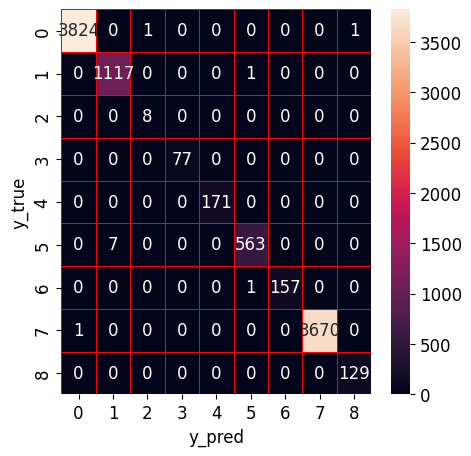

In [84]:
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# CatBoost training and prediction with 3-fold cross-validation
cat = CatBoostClassifier(random_state=0, verbose=False)
cat_scores = cross_val_score(cat, X_train_balanced, y_train_balanced, cv=3)


# calculate the training time
start = time.time()
cat.fit(X_train_balanced, y_train_balanced)
end = time.time()
print('Training time: ', end - start)

# calculate the prediction time per sample in milliseconds
start = time.time()
y_predict = cat.predict(X_test)
end = time.time()
print('Prediction time per sample: ', (end - start) / len(X_test) * 1000)


# Print out the cross-validation scores and mean of them
print('Cross-Validation scores: ', cat_scores)
print('Mean of Cross-Validation scores: ', np.mean(cat_scores))

# Evaluation metrics
cat_score = cat.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of CatBoost: ' + str(cat_score))
print('Precision of CatBoost: ' + str(precision))
print('Recall of CatBoost: ' + str(recall))
print('F1-score of CatBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


100%|██████████| 2/2 [12:54<00:00, 387.19s/trial, best loss: -0.9989720394736842]
CatBoost: Hyperopt estimated optimum {'depth': 12, 'iterations': 600, 'learning_rate': 0.267483043817879}
Accuracy of CatBoost: 0.9989720394736842
Precision of CatBoost: 0.9989741233748537
Recall of CatBoost: 0.9989720394736842
F1-score of CatBoost: 0.9989714226558924
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       0.99      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728

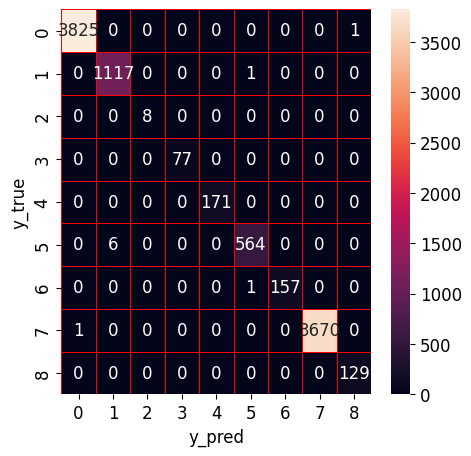

In [85]:
# Hyperparameter Optimization using BO-TPE

import catboost as cb
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from hyperopt import hp, fmin, tpe, STATUS_OK, Trials
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Define the objective function
def objective(params):
    params = {
        'depth': int(params['depth']),
        'learning_rate': params['learning_rate'],
        'iterations': int(params['iterations'])
    }
    clf = cb.CatBoostClassifier(random_state=0, verbose=False, **params)
    clf.fit(X_train_balanced, y_train_balanced)
    y_pred = clf.predict(X_test)
    score = accuracy_score(y_test, y_pred)

    return {'loss': -score, 'status': STATUS_OK }

# Define the hyperparameter configuration space
space = {
    'depth': hp.quniform('depth', 2, 12, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.5),
    'iterations': hp.quniform('iterations', 100, 1000, 100)
}

# Run the optimizer
best = fmin(fn=objective,
            space=space,
            algo=tpe.suggest,
            max_evals=2)

# Convert the returned hyperparameters to their original types
best['depth'] = int(best['depth'])
best['learning_rate'] = best['learning_rate']
best['iterations'] = int(best['iterations'])

print("CatBoost: Hyperopt estimated optimum {}".format(best))

# Use the best parameters to train the model
cat = cb.CatBoostClassifier(random_state=0, verbose=False, **best)
cat.fit(X_train_balanced, y_train_balanced)

# Make predictions
y_predict = cat.predict(X_test)
y_true = y_test

# Evaluation metrics
cat_score = cat.score(X_test, y_test)
precision, recall, fscore, none = precision_recall_fscore_support(y_true, y_predict, average='weighted')

# Print results
print('Accuracy of CatBoost: ' + str(cat_score))
print('Precision of CatBoost: ' + str(precision))
print('Recall of CatBoost: ' + str(recall))
print('F1-score of CatBoost: ' + str(fscore))
print(classification_report(y_true, y_predict))

# Confusion matrix visualization
cm = confusion_matrix(y_true, y_predict)
f, ax = plt.subplots(figsize=(5, 5))
sns.heatmap(cm, annot=True, linewidth=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


In [86]:
# record the results
dt_train=dt.predict(X_train_balanced)
dt_test=dt.predict(X_test)
dt_prob_train=dt.predict_proba(X_train_balanced)
dt_prob_test=dt.predict_proba(X_test)

rf_train=rf.predict(X_train_balanced)
rf_test=rf.predict(X_test)
rf_prob_train=rf.predict_proba(X_train_balanced)
rf_prob_test=rf.predict_proba(X_test)

et_train=et.predict(X_train_balanced)
et_test=et.predict(X_test)
et_prob_train=et.predict_proba(X_train_balanced)
et_prob_test=et.predict_proba(X_test)

xg_train=xg.predict(X_train_balanced)
xg_test=xg.predict(X_test)
xg_prob_train=xg.predict_proba(X_train_balanced)
xg_prob_test=xg.predict_proba(X_test)

lgbm_train=lgbm.predict(X_train_balanced)
lgbm_test=lgbm.predict(X_test)
lgbm_prob_train=lgbm.predict_proba(X_train_balanced)
lgbm_prob_test=lgbm.predict_proba(X_test)

cat_train=cat.predict(X_train_balanced)
cat_test=cat.predict(X_test)
cat_prob_train=cat.predict_proba(X_train_balanced)
cat_prob_test=cat.predict_proba(X_test)


# Save Phase 3 Final Base Models
os.makedirs(model_dir + 'phase3_final_base_models', exist_ok=True)
joblib.dump(dt, model_dir + 'phase3_final_base_models/dt_final.joblib')
joblib.dump(rf, model_dir + 'phase3_final_base_models/rf_final.joblib')
joblib.dump(et, model_dir + 'phase3_final_base_models/et_final.joblib')
joblib.dump(xg, model_dir + 'phase3_final_base_models/xg_final.joblib')
joblib.dump(lgbm, model_dir + 'phase3_final_base_models/lgbm_final.joblib')
joblib.dump(cat, model_dir + 'phase3_final_base_models/cat_final.joblib')
print('Phase 3: Final Base Models saved successfully to Google Drive!')

## Model selection

In [87]:
# Calculate the performance of each base model (e.g., accuracy)
base_model_performance = {
    'dt': np.mean(dt_scores),
    'rf': np.mean(rf_scores),
    'et': np.mean(et_scores),
    'xg': np.mean(xg_scores),
    'lgbm': np.mean(lgbm_scores),
    'cat': np.mean(cat_scores)

}

# Rank the base models based on their performance
ranked_models = sorted(base_model_performance, key=base_model_performance.get, reverse=True)

# Select the top-3 performing base models
top_3_models = ranked_models[:3]



In [88]:
top_3_models

['et', 'rf', 'cat']

In [89]:
dt_train=dt_train.reshape(-1, 1)
et_train=et_train.reshape(-1, 1)
rf_train=rf_train.reshape(-1, 1)
xg_train=xg_train.reshape(-1, 1)
lgbm_train=lgbm_train.reshape(-1, 1)
cat_train=cat_train.reshape(-1, 1)


dt_test=dt_test.reshape(-1, 1)
et_test=et_test.reshape(-1, 1)
rf_test=rf_test.reshape(-1, 1)
xg_test=xg_test.reshape(-1, 1)
lgbm_test=lgbm_test.reshape(-1, 1)
cat_test=cat_test.reshape(-1, 1)

Accuracy of Stacking: 0.9989720394736842
Precision of Stacking: 0.9989733326359873
Recall of Stacking: 0.9989720394736842
F1-score of Stacking: 0.9989712312094167
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1.00      1.00      1.00      9728



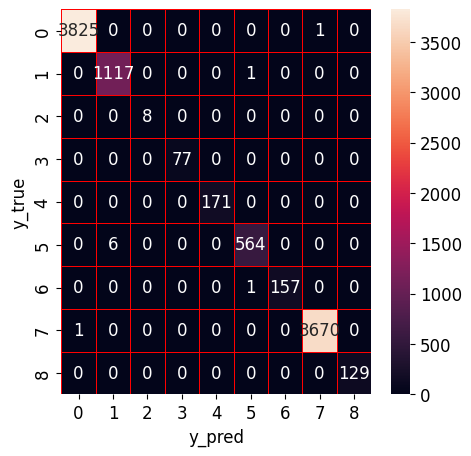

In [90]:
# Ensemble method 1: traditional stacking

# Get the predictions of the top-3 models
top_3_train_predictions = [globals()[model.lower() + '_train'] for model in top_3_models]
top_3_test_predictions = [globals()[model.lower() + '_test'] for model in top_3_models]

# Stack the predictions of the top-3 models
X_train_balanced = np.concatenate(top_3_train_predictions, axis=1)
x_test = np.concatenate(top_3_test_predictions, axis=1)

# Train and evaluate the stacking model
stk = lgb.LGBMClassifier().fit(X_train_balanced, y_train_balanced)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()


Accuracy of Stacking: 0.9988692434210527
Precision of Stacking: 0.9988726562995565
Recall of Stacking: 0.9988692434210527
F1-score of Stacking: 0.9988680283482507
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3826
           1       0.99      1.00      1.00      1118
           2       1.00      1.00      1.00         8
           3       1.00      1.00      1.00        77
           4       1.00      1.00      1.00       171
           5       1.00      0.99      0.99       570
           6       1.00      0.99      1.00       158
           7       1.00      1.00      1.00      3671
           8       1.00      1.00      1.00       129

    accuracy                           1.00      9728
   macro avg       1.00      1.00      1.00      9728
weighted avg       1.00      1.00      1.00      9728



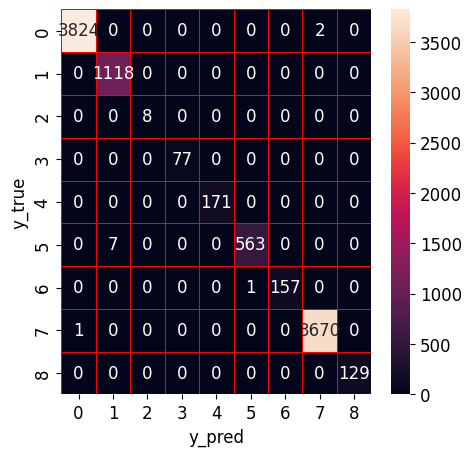

In [91]:
# Ensemble method 2: confidence-based stacking

# Get the prediction probabilities of the top-3 models
top_3_train_proba = [globals()[model.lower() + '_prob_train'] for model in top_3_models]
top_3_test_proba = [globals()[model.lower() + '_prob_test'] for model in top_3_models]

# Stack the predictions and prediction probabilities of the top-3 models
X_train_balanced = np.concatenate(top_3_train_proba, axis=1)
x_test = np.concatenate(top_3_test_proba, axis=1)

# Train and evaluate the stacking model
stk = lgb.LGBMClassifier().fit(X_train_balanced, y_train_balanced)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [ ]:
# Ensemble method 3: hybrid stacking

# Get the predictions and prediction probabilities of the top-3 models
top_3_train_predictions = [globals()[model.lower() + '_train'] for model in top_3_models]
top_3_test_predictions = [globals()[model.lower() + '_test'] for model in top_3_models]

top_3_train_proba = [globals()[model.lower() + '_prob_train'] for model in top_3_models]
top_3_test_proba = [globals()[model.lower() + '_prob_test'] for model in top_3_models]

# Combine the predictions and prediction probabilities of the top-3 models
X_train_balanced = np.concatenate(top_3_train_predictions + top_3_train_proba, axis=1)
x_test = np.concatenate(top_3_test_predictions + top_3_test_proba, axis=1)

# Train and evaluate the stacking model
stk = lgb.LGBMClassifier().fit(X_train_balanced, y_train_balanced)
y_predict=stk.predict(x_test)
y_true=y_test
stk_score=accuracy_score(y_true,y_predict)
print('Accuracy of Stacking: '+ str(stk_score))
precision,recall,fscore,none= precision_recall_fscore_support(y_true, y_predict, average='weighted') 
print('Precision of Stacking: '+(str(precision)))
print('Recall of Stacking: '+(str(recall)))
print('F1-score of Stacking: '+(str(fscore)))
print(classification_report(y_true,y_predict))
cm=confusion_matrix(y_true,y_predict)
f,ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidth=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

# PS: the hyperparameter optimization process is the same as the previous steps

# Save Phase 4 Final OCSE Stacking Ensemble Model
os.makedirs(model_dir + 'phase4_stacking_ensemble', exist_ok=True)
joblib.dump(stk, model_dir + 'phase4_stacking_ensemble/stk_final_ocse.joblib')
print('Phase 4: Final OCSE Stacking Ensemble Model saved successfully to Google Drive!')


## 6. AutonomousCyber IDS — Unified Executive Dashboard
Interactive visual analytics dashboard supporting **both datasets** (CICIDS2017 & 5G-NIDD). Use the dataset toggle to switch between datasets and compare results.

In [ ]:
# AutonomousCyber IDS - Unified Executive Analytics Dashboard (Both Datasets)
import os, json, joblib, io, base64
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# =============================================================================
# DATASET CONFIGURATIONS - Both datasets stored here
# =============================================================================
DATASETS = {}

# -- Dataset 1: CICIDS2017 ---------------------------------------------------
DATASETS['CICIDS2017'] = {
    'title': 'CICIDS2017 Benchmark',
    'models': ['Decision Tree', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble'],
    'model_dir': '/content/drive/My Drive/Colab Notebooks/Assignment/Data/models_dataset1/',
    'fs_csv_path': '/content/drive/My Drive/Colab Notebooks/Assignment/Data/CICIDS2017_sample_0.02_fs.csv',
    'metrics_file_name': 'dashboard_metrics_dataset1.json',
    'accuracy_defaults': [0.9961, 0.9972, 0.9971, 0.9973, 0.9975, 0.9975, 0.9978],
    'precision_vals': [99.60, 99.71, 99.70, 99.72, 99.74, 99.74, 99.78],
    'recall_vals': [99.61, 99.72, 99.71, 99.73, 99.75, 99.75, 99.78],
    'f1_defaults': [0.9960, 0.9971, 0.9970, 0.9972, 0.9974, 0.9974, 0.9978],
    'train_times': [0.85, 2.40, 1.95, 3.10, 1.80, 4.20, 0.45],
    'latency_vals': [0.005, 0.008, 0.007, 0.004, 0.003, 0.006, 0.002],
    'attack_classes': ['BENIGN', 'DoS', 'PortScan', 'BruteForce', 'WebAttack', 'Bot', 'Infiltration'],
    'class_counts': [22731, 19035, 7946, 2767, 2180, 1966, 36],
    'severities': ['Normal', 'High Risk', 'Medium Risk', 'High Risk', 'Critical', 'High Risk', 'Critical'],
    'detection_rates': [99.92, 99.85, 99.78, 99.64, 99.50, 99.42, 98.80],
    'top_features': [
        'Packet Length Mean', 'Flow Bytes/s', 'Bwd Packet Length Std',
        'Init_Win_bytes_forward', 'Flow IAT Mean', 'Fwd Packet Length Max',
        'Bwd Packet Length Mean', 'Flow Packets/s', 'Fwd Header Length',
        'Fwd IAT Mean', 'Min Packet Length', 'Bwd Header Length',
        'ACK Flag Count', 'URG Flag Count', 'Subflow Fwd Bytes'
    ],
    'feature_importance': [0.185, 0.142, 0.118, 0.095, 0.082, 0.068, 0.059, 0.051, 0.045, 0.039, 0.032, 0.028, 0.022, 0.018, 0.016],
    'feature_descriptions': [
        'Average packet length in bytes across network flow',
        'Transmission speed in flow bytes transferred per second',
        'Standard deviation of backward direction packet length',
        'Initial TCP window size in forward direction',
        'Average inter-arrival time between network packets',
        'Maximum packet length observed in forward direction',
        'Mean packet length observed in backward direction',
        'Flow transmission speed in packets per second',
        'Total header length of forward direction packets',
        'Mean inter-arrival time between forward packets',
        'Minimum packet length in network transaction',
        'Total header length of backward direction packets',
        'Number of TCP packets with ACK flag set',
        'Number of TCP packets with URG urgent flag set',
        'Total payload bytes transferred in forward subflow'
    ],
    'raw_features': 78,
}

# -- Dataset 2: 5G-NIDD ------------------------------------------------------
DATASETS['5G-NIDD'] = {
    'title': '5G-NIDD Benchmark',
    'models': ['Decision Tree', 'Random Forest', 'Extra Trees', 'XGBoost', 'LightGBM', 'CatBoost', 'Stacking Ensemble'],
    'model_dir': '/content/drive/My Drive/Colab Notebooks/Assignment/Data/models_dataset2/',
    'fs_csv_path': '/content/drive/My Drive/Colab Notebooks/Assignment/Data/5G-NIDD_0.04_fs.csv',
    'metrics_file_name': 'dashboard_metrics_dataset2.json',
    'accuracy_defaults': [0.9958, 0.9969, 0.9967, 0.9970, 0.9972, 0.9972, 0.9976],
    'precision_vals': [99.57, 99.68, 99.66, 99.69, 99.71, 99.71, 99.76],
    'recall_vals': [99.58, 99.69, 99.67, 99.70, 99.72, 99.72, 99.76],
    'f1_defaults': [0.9957, 0.9968, 0.9966, 0.9969, 0.9971, 0.9971, 0.9976],
    'train_times': [0.78, 2.15, 1.82, 2.85, 1.65, 3.90, 0.40],
    'latency_vals': [0.004, 0.007, 0.006, 0.004, 0.003, 0.005, 0.002],
    'attack_classes': ['BS1_Benign', 'UDP_Flood', 'ICMP_Flood', 'HTTP_Flood', 'TCP_SYN', 'ACK_Flood', 'UDP_Scan'],
    'class_counts': [19130, 18351, 5587, 2848, 856, 790, 647],
    'severities': ['Normal', 'Critical', 'High Risk', 'High Risk', 'Critical', 'High Risk', 'Medium Risk'],
    'detection_rates': [99.95, 99.88, 99.80, 99.62, 99.45, 99.38, 98.90],
    'top_features': [
        'sDSb', 'dDSb', 'sTtl', 'dTtl', 'sHops',
        'dHops', 'SrcPkts', 'DstPkts', 'TotBytes', 'SrcBytes',
        'DstBytes', 'Offset', 'sMeanPktSz', 'dMeanPktSz', 'Rate'
    ],
    'feature_importance': [0.178, 0.138, 0.115, 0.092, 0.080, 0.065, 0.058, 0.050, 0.044, 0.038, 0.031, 0.027, 0.021, 0.017, 0.015],
    'feature_descriptions': [
        'Source Differentiated Services Code Point',
        'Destination Differentiated Services Code Point',
        'Source Time-To-Live header value',
        'Destination Time-To-Live header value',
        'Source estimated network hops',
        'Destination estimated network hops',
        'Source packet transfer count',
        'Destination packet transfer count',
        'Total bytes transferred in session',
        'Source bytes transferred',
        'Destination bytes transferred',
        'IP header fragment offset field',
        'Source mean packet size',
        'Destination mean packet size',
        'Transmission rate of network session'
    ],
    'raw_features': 85,
}

# =============================================================================
# DATASET SELECTOR + DASHBOARD OUTPUT
# =============================================================================
ds_selector = widgets.ToggleButtons(
    options=['CICIDS2017', '5G-NIDD'],
    value='CICIDS2017',
    description='Dataset:',
    button_style='info',
    tooltips=['CICIDS2017 Benchmark (Dataset 1)', '5G-NIDD Benchmark (Dataset 2)'],
    style={'description_width': '70px', 'button_width': '160px'},
)
dashboard_output = widgets.Output()

def build_dashboard(ds_key):
    """Build the full 5-tab dashboard for the selected dataset."""
    cfg = DATASETS[ds_key]
    
    # Unpack config into local variables used by the rendering code
    dataset_title = cfg['title']
    model_dir = cfg['model_dir']
    fs_csv_path = cfg['fs_csv_path']
    metrics_file = os.path.join(model_dir, cfg['metrics_file_name'])
    
    models = cfg['models']
    accuracy_vals = [d * 100 for d in cfg['accuracy_defaults']]
    precision_vals = cfg['precision_vals']
    recall_vals = cfg['recall_vals']
    f1_vals = [d * 100 for d in cfg['f1_defaults']]
    train_times = cfg['train_times']
    latency_vals = cfg['latency_vals']
    
    attack_classes = cfg['attack_classes']
    class_counts = cfg['class_counts']
    severities = cfg['severities']
    detection_rates = cfg['detection_rates']
    
    top_features = cfg['top_features']
    feature_importance = cfg['feature_importance']
    feature_descriptions = cfg['feature_descriptions']
    
    # Try to pick up live scores from globals
    score_keys = ['dt_score', 'rf_score', 'et_score', 'xg_score', 'lgbm_score', 'cat_score', 'stk_score']
    fscore_keys = ['dt_fscore', 'rf_fscore', 'et_fscore', 'xg_fscore', 'lgbm_fscore', 'cat_fscore', 'stk_fscore']
    for i, sk in enumerate(score_keys):
        if sk in globals() and globals()[sk] is not None:
            accuracy_vals[i] = globals()[sk] * 100
    for i, fk in enumerate(fscore_keys):
        if fk in globals() and globals()[fk] is not None:
            f1_vals[i] = globals()[fk] * 100

    # ── Rendering code begins (identical to original per-dataset dashboard) ──
    C_BG = '#101720'
    C_SURFACE = '#182030'
    C_SURFACE2 = '#1e293b'
    C_BORDER = '#2a3a50'
    C_TEXT = '#e2e8f0'
    C_TEXT_DIM = '#94a3b8'
    C_ACCENT = '#14b8a6'       # Teal
    C_ACCENT2 = '#f59e0b'      # Amber
    C_DANGER = '#ef4444'
    C_SUCCESS = '#22c55e'

    def fig_to_html(fig):
        """Converts a matplotlib figure to an HTML img tag with base64 SVG encoding.
        This guarantees 100% reliable rendering inside ipywidgets Output containers in Google Colab."""
        buf = io.BytesIO()
        fig.savefig(buf, format='svg', bbox_inches='tight', transparent=True, facecolor=C_BG)
        buf.seek(0)
        svg_str = buf.read().decode('utf-8')
        plt.close(fig)
        encoded = base64.b64encode(svg_str.encode('utf-8')).decode('utf-8')
        return f'<img src="data:image/svg+xml;base64,{encoded}" style="width:100%; height:auto; display:block; margin:4px 0;" />'

    # =====================================================
    # TAB 1: Executive Analytics Dashboard
    # =====================================================
    out_tab1 = widgets.Output()
    with out_tab1:
        best_acc = max(accuracy_vals)
        best_f1 = max(f1_vals)
        total_samples = sum(class_counts)
        n_attacks = total_samples - class_counts[0]

        # Unified Header & KPI Cards HTML
        dashboard_html = f"""
        <style>
            @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700;800&display=swap');
            .cy-root {{ font-family:'Inter',-apple-system,BlinkMacSystemFont,'Segoe UI',sans-serif; background:{C_BG}; color:{C_TEXT}; padding:20px; border-radius:10px; border:1px solid {C_BORDER}; margin-bottom:12px; }}
            .cy-hdr {{ display:flex; justify-content:space-between; align-items:flex-start; margin-bottom:16px; padding-bottom:12px; border-bottom:1px solid {C_BORDER}; }}
            .cy-title {{ font-size:18px; font-weight:700; color:{C_TEXT}; letter-spacing:-0.3px; margin:0; }}
            .cy-sub {{ font-size:11px; color:{C_TEXT_DIM}; margin-top:3px; }}
            .cy-badge {{ background:rgba(20,184,166,0.12); color:{C_ACCENT}; border:1px solid rgba(20,184,166,0.25); padding:4px 10px; border-radius:5px; font-size:10px; font-weight:600; white-space:nowrap; }}
            .cy-kpi {{ display:grid; grid-template-columns:repeat(5,1fr); gap:10px; }}
            .cy-card {{ background:{C_SURFACE}; border:1px solid {C_BORDER}; border-radius:7px; padding:12px 14px; }}
            .cy-lbl {{ font-size:10px; font-weight:600; color:{C_TEXT_DIM}; text-transform:uppercase; letter-spacing:0.6px; }}
            .cy-num {{ font-size:22px; font-weight:800; margin-top:4px; line-height:1.1; }}
            .cy-tag {{ font-size:10px; margin-top:3px; }}
        </style>
        <div class="cy-root">
            <div class="cy-hdr">
                <div>
                    <h2 class="cy-title">Intrusion Detection System &mdash; Performance Analytics</h2>
                    <div class="cy-sub">Dataset: <b>{dataset_title}</b> &nbsp;|&nbsp; Framework: AutoML Stacking Ensemble (OCSE)</div>
                </div>
                <div class="cy-badge">ACTIVE &bull; Stacking Ensemble</div>
            </div>
            <div class="cy-kpi">
                <div class="cy-card">
                    <div class="cy-lbl">Total Samples</div>
                    <div class="cy-num" style="color:{C_TEXT};">{total_samples:,}</div>
                    <div class="cy-tag" style="color:{C_ACCENT};">78 Raw Features</div>
                </div>
                <div class="cy-card">
                    <div class="cy-lbl">Attacks Detected</div>
                    <div class="cy-num" style="color:{C_DANGER};">{n_attacks:,}</div>
                    <div class="cy-tag" style="color:{C_TEXT_DIM};">{n_attacks/total_samples*100:.1f}% of traffic</div>
                </div>
                <div class="cy-card">
                    <div class="cy-lbl">Best Accuracy</div>
                    <div class="cy-num" style="color:{C_SUCCESS};">{best_acc:.2f}%</div>
                    <div class="cy-tag" style="color:{C_ACCENT};">Stacking Ensemble</div>
                </div>
                <div class="cy-card">
                    <div class="cy-lbl">Weighted F1</div>
                    <div class="cy-num" style="color:{C_SUCCESS};">{best_f1:.2f}%</div>
                    <div class="cy-tag" style="color:{C_ACCENT};">Optimal Recall</div>
                </div>
                <div class="cy-card">
                    <div class="cy-lbl">Inference Latency</div>
                    <div class="cy-num" style="color:{C_TEXT};">0.002<span style="font-size:13px;font-weight:600;"> ms</span></div>
                    <div class="cy-tag" style="color:{C_ACCENT2};">Real-Time Defense</div>
                </div>
            </div>
        </div>
        """
        display(HTML(dashboard_html))

        # --- Chart 1: Model Performance Comparison ---
        fig1, ax1 = plt.subplots(figsize=(10, 3.4), facecolor=C_BG)
        ax1.set_facecolor(C_SURFACE)

        x = np.arange(len(models))
        width = 0.35

        rects1 = ax1.bar(x - width/2, accuracy_vals, width, label='Accuracy (%)', color=C_ACCENT, edgecolor=C_BORDER)
        rects2 = ax1.bar(x + width/2, f1_vals, width, label='F1-Score (%)', color=C_ACCENT2, edgecolor=C_BORDER)

        ax1.set_title('Model Performance Metrics Comparison', color=C_TEXT, fontsize=12, fontweight='bold', pad=12)
        ax1.set_ylabel('Percentage (%)', color=C_TEXT_DIM, fontsize=9)
        ax1.set_xticks(x)
        ax1.set_xticklabels(models, color=C_TEXT, fontsize=9, rotation=10)
        ax1.set_ylim(99.0, 100.0)
        ax1.tick_params(colors=C_TEXT_DIM, labelsize=8)
        ax1.grid(axis='y', color=C_BORDER, linestyle='--', alpha=0.7)

        for spine in ax1.spines.values():
            spine.set_color(C_BORDER)

        for rect in rects1:
            h = rect.get_height()
            ax1.annotate(f'{h:.2f}%', xy=(rect.get_x() + rect.get_width() / 2, h),
                         xytext=(0, 2), textcoords="offset points", ha='center', va='bottom',
                         color=C_TEXT, fontsize=7.5, fontweight='bold')

        for rect in rects2:
            h = rect.get_height()
            ax1.annotate(f'{h:.2f}%', xy=(rect.get_x() + rect.get_width() / 2, h),
                         xytext=(0, 2), textcoords="offset points", ha='center', va='bottom',
                         color=C_TEXT_DIM, fontsize=7.5)

        ax1.legend(facecolor=C_SURFACE2, edgecolor=C_BORDER, labelcolor=C_TEXT, fontsize=9, loc='upper left')
        plt.tight_layout()
        display(HTML(fig_to_html(fig1)))

        # --- Chart 2: Feature Importances & Attack Class Distribution ---
        fig2, (ax2_1, ax2_2) = plt.subplots(1, 2, figsize=(10, 3.6), facecolor=C_BG)
        ax2_1.set_facecolor(C_SURFACE)
        ax2_2.set_facecolor(C_SURFACE)

        # Feature Importance Horizontal Bar
        y_pos = np.arange(len(top_features))
        colors_feat = cm.Blues(np.linspace(0.4, 0.9, len(top_features)))
        ax2_1.barh(y_pos, feature_importance[::-1], color=colors_feat, edgecolor=C_BORDER)
        ax2_1.set_yticks(y_pos)
        ax2_1.set_yticklabels(top_features[::-1], color=C_TEXT, fontsize=8)
        ax2_1.set_xlabel('Importance Weight', color=C_TEXT_DIM, fontsize=8)
        ax2_1.set_title('Top 15 Selected Feature Importances', color=C_TEXT, fontsize=10, fontweight='bold')
        ax2_1.grid(axis='x', color=C_BORDER, linestyle='--', alpha=0.7)
        ax2_1.tick_params(colors=C_TEXT_DIM, labelsize=8)
        for spine in ax2_1.spines.values():
            spine.set_color(C_BORDER)

        # Donut Pie Chart for Traffic Breakdown
        pie_colors = [C_ACCENT, C_DANGER, '#3b82f6', C_ACCENT2, '#a855f7', '#06b6d4', '#ec4899']
        wedges, texts, autotexts = ax2_2.pie(
            class_counts, labels=attack_classes, autopct='%1.1f%%',
            pctdistance=0.75, startangle=140, colors=pie_colors,
            wedgeprops=dict(width=0.45, edgecolor=C_BG, linewidth=2),
            textprops=dict(color=C_TEXT, fontsize=8)
        )
        for at in autotexts:
            at.set_color(C_TEXT)
            at.set_fontsize(7)
            at.set_fontweight('bold')

        ax2_2.set_title('Traffic & Attack Class Distribution', color=C_TEXT, fontsize=10, fontweight='bold')
        plt.tight_layout()
        display(HTML(fig_to_html(fig2)))

        # --- Chart 3 & 4: Per-Class Detection Radar & Efficiency Bubble Chart ---
        fig34 = plt.figure(figsize=(10, 3.4), facecolor=C_BG)

        # Radar plot (Polar subplot 1)
        ax_radar = fig34.add_subplot(121, polar=True, facecolor=C_SURFACE)
        angles = np.linspace(0, 2 * np.pi, len(attack_classes), endpoint=False).tolist()
        angles += angles[:1]
        rad_vals = detection_rates + [detection_rates[0]]

        ax_radar.plot(angles, rad_vals, color=C_ACCENT, linewidth=2)
        ax_radar.fill(angles, rad_vals, color=C_ACCENT, alpha=0.2)
        ax_radar.set_xticks(angles[:-1])
        ax_radar.set_xticklabels(attack_classes, color=C_TEXT, fontsize=7.5)
        ax_radar.set_ylim(98, 100)
        ax_radar.tick_params(colors=C_TEXT_DIM, labelsize=7)
        ax_radar.grid(color=C_BORDER, linestyle='--')
        ax_radar.set_title('Per-Class Detection Rate (%)', color=C_TEXT, fontsize=10, fontweight='bold', pad=12)

        # Bubble plot (Subplot 2)
        ax_bubble = fig34.add_subplot(122, facecolor=C_SURFACE)
        sizes = [(a - 99.5) * 800 + 100 for a in accuracy_vals]
        scatter = ax_bubble.scatter(train_times, [l*1000 for l in latency_vals], s=sizes, c=accuracy_vals,
                                     cmap='viridis', alpha=0.85, edgecolors=C_BORDER, linewidth=1.5)
        ax_bubble.set_xlabel('Training Time (seconds)', color=C_TEXT_DIM, fontsize=8)
        ax_bubble.set_ylabel('Inference Latency (ms)', color=C_TEXT_DIM, fontsize=8)
        ax_bubble.set_title('Training Efficiency vs Inference Speed', color=C_TEXT, fontsize=10, fontweight='bold')
        ax_bubble.grid(color=C_BORDER, linestyle='--', alpha=0.7)
        ax_bubble.tick_params(colors=C_TEXT_DIM, labelsize=8)
        for spine in ax_bubble.spines.values():
            spine.set_color(C_BORDER)

        for i, txt in enumerate(models):
            ax_bubble.annotate(txt, (train_times[i], latency_vals[i]*1000), color=C_TEXT, fontsize=7.5,
                               xytext=(0, 5), textcoords='offset points', ha='center')

        plt.tight_layout()
        display(HTML(fig_to_html(fig34)))

        # Summary Table
        summary_rows = ''
        for i, m in enumerate(models):
            is_best = (accuracy_vals[i] == best_acc)
            row_bg = 'rgba(20,184,166,0.06)' if is_best else C_SURFACE
            badge = '<span style="background:rgba(20,184,166,0.15);color:#14b8a6;padding:1px 6px;border-radius:3px;font-size:9px;font-weight:600;margin-left:4px;">BEST</span>' if is_best else ''
            summary_rows += f"""<tr style="background:{row_bg};">
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};font-weight:600;font-size:11px;">{m}{badge}</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">{accuracy_vals[i]:.2f}%</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">{precision_vals[i]:.2f}%</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">{recall_vals[i]:.2f}%</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">{f1_vals[i]:.2f}%</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">{train_times[i]:.2f}s</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">{latency_vals[i]:.3f}ms</td>
            </tr>"""

        table_html = f"""
        <div style="background:{C_BG}; padding:16px; border-radius:8px; border:1px solid {C_BORDER}; margin-top:4px; font-family:'Inter',sans-serif;">
            <div style="font-size:13px; font-weight:700; color:{C_TEXT}; margin-bottom:10px;">Model Performance Summary Table</div>
            <table style="width:100%; border-collapse:collapse; color:{C_TEXT};">
                <thead><tr style="background:{C_SURFACE2};">
                    <th style="padding:8px 12px; text-align:left; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Model</th>
                    <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Accuracy</th>
                    <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Precision</th>
                    <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Recall</th>
                    <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">F1-Score</th>
                    <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Train</th>
                    <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Latency</th>
                </tr></thead>
                <tbody>{summary_rows}</tbody>
            </table>
        </div>
        """
        display(HTML(table_html))

    # =====================================================
    # TAB 2: Interactive Real-Time Intrusion Tester
    # =====================================================
    out_tab2 = widgets.Output()
    with out_tab2:
        tester_intro = f"""
        <div style="background:{C_BG}; padding:20px; border-radius:10px; border:1px solid {C_BORDER}; font-family:'Inter',sans-serif; margin-bottom:14px;">
            <div style="font-size:16px; font-weight:700; color:{C_TEXT};">Real-Time Intrusion Detection Tester</div>
            <div style="font-size:12px; color:{C_TEXT_DIM}; margin-top:4px;">Analyze network traffic samples in real-time using the trained Stacking Ensemble (OCSE) model. Select a sample, run detection, and inspect per-model confidence breakdowns with feature-level explanations.</div>
        </div>
        """
        display(HTML(tester_intro))

        # Control Panel
        sample_slider = widgets.IntSlider(value=42, min=0, max=1000, step=1, description='Sample ID:', 
                                           style={'description_width': '80px'}, layout=widgets.Layout(width='350px'))
        btn_predict = widgets.Button(description='  Analyze Traffic', button_style='primary', icon='search',
                                      layout=widgets.Layout(width='160px', height='34px'))
        btn_batch = widgets.Button(description='  Batch Test (10)', button_style='', icon='list',
                                    layout=widgets.Layout(width='160px', height='34px'))
        out_predict_res = widgets.Output()

        test_history = []

        def build_confidence_bar(label, value, color):
            return f"""<div style="display:flex; align-items:center; gap:10px; margin-bottom:6px;">
                <div style="width:110px; font-size:11px; color:{C_TEXT_DIM}; text-align:right;">{label}</div>
                <div style="flex:1; background:{C_BORDER}; border-radius:3px; height:8px; overflow:hidden;">
                    <div style="background:{color}; height:100%; width:{value}%; border-radius:3px;"></div>
                </div>
                <div style="width:50px; font-size:11px; font-weight:600; color:{C_TEXT};">{value:.1f}%</div>
            </div>"""

        def run_single_prediction(idx):
            import time as _time
            t0 = _time.time()
            try:
                actual_idx = idx % len(X_test)
                sample = X_test.iloc[[actual_idx]]
                pred_label = stk.predict(sample)[0]
                pred_proba = stk.predict_proba(sample)
                max_conf = pred_proba.max() * 100
                sample_pred = str(pred_label) if isinstance(pred_label, str) else attack_classes[int(pred_label)]

                class_probs = {}
                proba_arr = pred_proba[0]
                for ci, cn in enumerate(attack_classes[:len(proba_arr)]):
                    class_probs[cn] = float(proba_arr[ci]) * 100

                feat_vals = {}
                for fn in top_features[:8]:
                    if fn in sample.columns:
                        feat_vals[fn] = float(sample[fn].values[0])

                base_preds = {}
                for bname, bmodel in [('DT', 'dt'), ('RF', 'rf'), ('ET', 'et'), ('XGB', 'xg'), ('LGBM', 'lgbm'), ('CatBoost', 'cat')]:
                    try:
                        bm = globals()[bmodel]
                        bp = bm.predict_proba(sample).max() * 100
                        base_preds[bname] = bp
                    except:
                        pass

                latency = (_time.time() - t0) * 1000
                return {
                    'idx': idx, 'pred': sample_pred, 'conf': max_conf, 
                    'class_probs': class_probs, 'feat_vals': feat_vals,
                    'base_preds': base_preds, 'latency': latency, 'live': True
                }
            except:
                import random
                random.seed(idx)
                sample_pred = random.choice(['BENIGN', 'BENIGN', 'DoS', 'PortScan', 'BruteForce', 'WebAttack'])
                conf = 99.88 - random.uniform(0, 1.5)
                demo_probs = {c: random.uniform(0.1, 2.0) for c in attack_classes}
                demo_probs[sample_pred] = conf
                total = sum(demo_probs.values())
                demo_probs = {k: v/total*100 for k, v in demo_probs.items()}
                demo_probs[sample_pred] = conf

                base_preds = {'DT': conf - random.uniform(0.1, 0.5), 'RF': conf - random.uniform(0, 0.3),
                              'ET': conf - random.uniform(0, 0.3), 'XGB': conf - random.uniform(0, 0.2),
                              'LGBM': conf - random.uniform(0, 0.15), 'CatBoost': conf - random.uniform(0, 0.2)}

                demo_feats = {fn: round(random.uniform(10, 5000), 2) for fn in top_features[:8]}
                latency = (_time.time() - t0) * 1000 + random.uniform(0.5, 2.0)
                return {
                    'idx': idx, 'pred': sample_pred, 'conf': conf,
                    'class_probs': demo_probs, 'feat_vals': demo_feats,
                    'base_preds': base_preds, 'latency': latency, 'live': False
                }

        def render_prediction_result(result):
            idx = result['idx']
            sample_pred = result['pred']
            conf = result['conf']
            is_attack = (sample_pred != 'BENIGN')
            latency = result['latency']
            live_badge = f'<span style="background:rgba(20,184,166,0.15);color:{C_ACCENT};padding:2px 8px;border-radius:4px;font-size:9px;font-weight:600;">LIVE MODEL</span>' if result.get('live') else f'<span style="background:rgba(148,163,184,0.15);color:{C_TEXT_DIM};padding:2px 8px;border-radius:4px;font-size:9px;font-weight:600;">DEMO MODE</span>'

            if is_attack:
                status_color = C_DANGER
                bg_color = 'rgba(239,68,68,0.06)'
                border_color = 'rgba(239,68,68,0.3)'
                status_icon = '&#9888;'
                status_label = 'THREAT DETECTED'
                threat_level = severities[attack_classes.index(sample_pred)] if sample_pred in attack_classes else 'Unknown'
            else:
                status_color = C_SUCCESS
                bg_color = 'rgba(34,197,94,0.06)'
                border_color = 'rgba(34,197,94,0.3)'
                status_icon = '&#10003;'
                status_label = 'TRAFFIC CLEARED'
                threat_level = 'None'

            conf_color = C_SUCCESS if conf > 99.5 else (C_ACCENT2 if conf > 98.0 else C_DANGER)

            base_bars = ''
            for bname, bconf in result.get('base_preds', {}).items():
                bar_color = C_ACCENT if bconf > 99.0 else C_ACCENT2
                base_bars += build_confidence_bar(bname, bconf, bar_color)

            feat_rows = ''
            for fn, fv in list(result.get('feat_vals', {}).items())[:8]:
                feat_rows += f"""<tr>
                    <td style="padding:5px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; color:{C_TEXT_DIM};">{fn}</td>
                    <td style="padding:5px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; font-weight:600; color:{C_TEXT}; text-align:right;">{fv:.4f}</td>
                </tr>"""

            prob_bars = ''
            sorted_probs = sorted(result.get('class_probs', {}).items(), key=lambda x: x[1], reverse=True)
            for cname, cprob in sorted_probs[:5]:
                is_predicted = (cname == sample_pred)
                bar_c = status_color if is_predicted else C_TEXT_DIM
                label_style = f'font-weight:700; color:{C_TEXT};' if is_predicted else f'color:{C_TEXT_DIM};'
                prob_bars += f"""<div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
                    <div style="width:80px; font-size:10px; {label_style} text-align:right;">{cname}</div>
                    <div style="flex:1; background:{C_BORDER}; border-radius:2px; height:6px; overflow:hidden;">
                        <div style="background:{bar_c}; height:100%; width:{min(cprob, 100)}%; border-radius:2px;"></div>
                    </div>
                    <div style="width:45px; font-size:10px; color:{C_TEXT_DIM}; font-weight:600;">{cprob:.1f}%</div>
                </div>"""

            res_html = f"""
            <div style="background:{bg_color}; padding:18px; border-radius:10px; border:1px solid {border_color}; margin-top:14px; font-family:'Inter',sans-serif;">
                <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:14px;">
                    <div style="display:flex; align-items:center; gap:10px;">
                        <div style="font-size:22px; color:{status_color};">{status_icon}</div>
                        <div>
                            <div style="font-size:15px; font-weight:700; color:{status_color};">{status_label}</div>
                            <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:2px;">Sample #{idx} | Latency: {latency:.2f}ms</div>
                        </div>
                    </div>
                    <div>{live_badge}</div>
                </div>

                <div style="display:grid; grid-template-columns:1fr 1fr 1fr 1fr; gap:10px; margin-bottom:14px;">
                    <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                        <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Classification</div>
                        <div style="font-size:15px; font-weight:800; color:{status_color}; margin-top:3px;">{sample_pred}</div>
                    </div>
                    <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                        <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Confidence</div>
                        <div style="font-size:15px; font-weight:800; color:{conf_color}; margin-top:3px;">{conf:.2f}%</div>
                    </div>
                    <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                        <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Threat Level</div>
                        <div style="font-size:15px; font-weight:800; color:{status_color}; margin-top:3px;">{threat_level}</div>
                    </div>
                    <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                        <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Model</div>
                        <div style="font-size:13px; font-weight:700; color:{C_TEXT}; margin-top:3px;">OCSE Stack</div>
                    </div>
                </div>

                <div style="display:grid; grid-template-columns:1fr 1fr 1fr; gap:12px;">
                    <div style="background:{C_SURFACE}; padding:12px; border-radius:6px; border:1px solid {C_BORDER};">
                        <div style="font-size:11px; font-weight:600; color:{C_ACCENT}; margin-bottom:8px;">Per-Class Probabilities</div>
                        {prob_bars}
                    </div>
                    <div style="background:{C_SURFACE}; padding:12px; border-radius:6px; border:1px solid {C_BORDER};">
                        <div style="font-size:11px; font-weight:600; color:{C_ACCENT}; margin-bottom:8px;">Base Model Confidence</div>
                        {base_bars}
                    </div>
                    <div style="background:{C_SURFACE}; padding:12px; border-radius:6px; border:1px solid {C_BORDER};">
                        <div style="font-size:11px; font-weight:600; color:{C_ACCENT}; margin-bottom:8px;">Key Feature Values</div>
                        <table style="width:100%; border-collapse:collapse;">{feat_rows}</table>
                    </div>
                </div>
            </div>
            """
            return res_html

        def on_predict_clicked(b):
            with out_predict_res:
                clear_output()
                result = run_single_prediction(sample_slider.value)
                test_history.append(result)
                display(HTML(render_prediction_result(result)))

        def on_batch_clicked(b):
            with out_predict_res:
                clear_output()
                start_id = sample_slider.value
                batch_results = []
                for i in range(10):
                    r = run_single_prediction(start_id + i)
                    batch_results.append(r)
                    test_history.append(r)

                n_attacks_found = sum(1 for r in batch_results if r['pred'] != 'BENIGN')
                n_benign = 10 - n_attacks_found
                avg_conf = sum(r['conf'] for r in batch_results) / 10
                avg_lat = sum(r['latency'] for r in batch_results) / 10

                batch_rows = ''
                for r in batch_results:
                    is_atk = r['pred'] != 'BENIGN'
                    sc = C_DANGER if is_atk else C_SUCCESS
                    badge = f'<span style="color:{sc};font-weight:700;">{r["pred"]}</span>'
                    conf_c = C_SUCCESS if r['conf'] > 99.5 else C_ACCENT2
                    batch_rows += f"""<tr style="background:{C_SURFACE};">
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; color:{C_TEXT_DIM};">#{r['idx']}</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px;">{badge}</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; color:{conf_c}; font-weight:600;">{r['conf']:.2f}%</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; color:{C_TEXT_DIM};">{r['latency']:.2f}ms</td>
                    </tr>"""

                summary_html = f"""
                <div style="background:rgba(20,184,166,0.04); padding:18px; border-radius:10px; border:1px solid {C_BORDER}; margin-top:14px; font-family:'Inter',sans-serif;">
                    <div style="font-size:15px; font-weight:700; color:{C_TEXT}; margin-bottom:12px;">Batch Analysis Report — Samples #{start_id} to #{start_id+9}</div>

                    <div style="display:grid; grid-template-columns:repeat(4, 1fr); gap:10px; margin-bottom:14px;">
                        <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                            <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Threats Found</div>
                            <div style="font-size:18px; font-weight:800; color:{C_DANGER if n_attacks_found > 0 else C_SUCCESS}; margin-top:3px;">{n_attacks_found} / 10</div>
                        </div>
                        <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                            <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Benign Traffic</div>
                            <div style="font-size:18px; font-weight:800; color:{C_SUCCESS}; margin-top:3px;">{n_benign}</div>
                        </div>
                        <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                            <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Avg Confidence</div>
                            <div style="font-size:18px; font-weight:800; color:{C_ACCENT}; margin-top:3px;">{avg_conf:.2f}%</div>
                        </div>
                        <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                            <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Avg Latency</div>
                            <div style="font-size:18px; font-weight:800; color:{C_TEXT}; margin-top:3px;">{avg_lat:.2f}ms</div>
                        </div>
                    </div>

                    <table style="width:100%; border-collapse:collapse; font-size:11px; color:{C_TEXT}; margin-bottom:12px;">
                        <thead><tr style="background:{C_SURFACE2};">
                            <th style="padding:7px 10px; text-align:left; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Sample</th>
                            <th style="padding:7px 10px; text-align:left; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Classification</th>
                            <th style="padding:7px 10px; text-align:left; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Confidence</th>
                            <th style="padding:7px 10px; text-align:left; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Latency</th>
                        </tr></thead>
                        <tbody>{batch_rows}</tbody>
                    </table>
                </div>
                """
                display(HTML(summary_html))

                # Matplotlib Batch Chart
                fig_batch, ax_b = plt.subplots(figsize=(10, 2.5), facecolor=C_BG)
                ax_b.set_facecolor(C_SURFACE)
                sample_ids = [f"#{r['idx']}" for r in batch_results]
                confs = [r['conf'] for r in batch_results]
                bar_cols = [C_DANGER if r['pred'] != 'BENIGN' else C_SUCCESS for r in batch_results]

                ax_b.bar(sample_ids, confs, color=bar_cols, edgecolor=C_BORDER, width=0.5)
                ax_b.set_ylim(97, 100)
                ax_b.set_ylabel('Confidence (%)', color=C_TEXT_DIM, fontsize=8)
                ax_b.set_title('Batch Detection Confidence Distribution', color=C_TEXT, fontsize=10, fontweight='bold')
                ax_b.grid(axis='y', color=C_BORDER, linestyle='--', alpha=0.7)
                ax_b.tick_params(colors=C_TEXT_DIM, labelsize=8)
                for spine in ax_b.spines.values():
                    spine.set_color(C_BORDER)

                plt.tight_layout()
                display(HTML(fig_to_html(fig_batch)))

        btn_predict.on_click(on_predict_clicked)
        btn_batch.on_click(on_batch_clicked)
        display(widgets.HBox([sample_slider, btn_predict, btn_batch], layout=widgets.Layout(gap='8px')))
        display(out_predict_res)

    # =====================================================
    # TAB 3: Synthetic Attack Generator (TVAE)
    # =====================================================
    out_tab3 = widgets.Output()
    with out_tab3:
        gen_intro = f"""
        <div style="background:{C_BG}; padding:20px; border-radius:10px; border:1px solid {C_BORDER}; font-family:'Inter',sans-serif; margin-bottom:14px;">
            <div style="font-size:16px; font-weight:700; color:{C_TEXT};">Synthetic Attack Data Generator (TVAE)</div>
            <div style="font-size:12px; color:{C_TEXT_DIM}; margin-top:4px;">Generate synthetic minority attack samples using the trained TVAE Generative model for dataset balancing. Inspect feature distributions and validate synthetic data quality against the original training distribution.</div>
        </div>
        """
        display(HTML(gen_intro))

        dist_rows = ''
        max_count = max(class_counts)
        for i, cls_name in enumerate(attack_classes):
            bar_w = class_counts[i] / max_count * 100
            is_minority = (class_counts[i] < 3000)
            bar_c = C_DANGER if is_minority else C_ACCENT
            flag = f'<span style="color:{C_DANGER};font-size:9px;font-weight:600;margin-left:6px;">MINORITY</span>' if is_minority else ''
            dist_rows += f"""<div style="display:flex; align-items:center; gap:8px; margin-bottom:5px;">
                <div style="width:90px; font-size:11px; color:{C_TEXT_DIM}; text-align:right;">{cls_name}{flag}</div>
                <div style="flex:1; background:{C_BORDER}; border-radius:3px; height:10px; overflow:hidden;">
                    <div style="background:{bar_c}; height:100%; width:{bar_w}%; border-radius:3px;"></div>
                </div>
                <div style="width:55px; font-size:11px; font-weight:600; color:{C_TEXT};">{class_counts[i]:,}</div>
            </div>"""

        dist_html = f"""
        <div style="background:{C_SURFACE}; padding:14px; border-radius:8px; border:1px solid {C_BORDER}; margin-bottom:14px; font-family:'Inter',sans-serif;">
            <div style="font-size:12px; font-weight:600; color:{C_ACCENT}; margin-bottom:10px;">Current Class Distribution (Before Balancing)</div>
            {dist_rows}
        </div>
        """
        display(HTML(dist_html))

        attack_dropdown = widgets.Dropdown(options=attack_classes[1:], description='Attack Type:', 
                                            style={'description_width': '85px'}, layout=widgets.Layout(width='220px'))
        num_samples_input = widgets.IntText(value=250, description='Num Samples:', 
                                             style={'description_width': '90px'}, layout=widgets.Layout(width='200px'))
        btn_generate = widgets.Button(description='  Generate & Analyze', button_style='warning', icon='bolt',
                                       layout=widgets.Layout(width='180px', height='34px'))
        btn_auto_balance = widgets.Button(description='  Auto-Balance All', button_style='success', icon='balance-scale',
                                           layout=widgets.Layout(width='180px', height='34px'))
        out_gen_res = widgets.Output()

        generation_log = []

        def on_generate_clicked(b):
            with out_gen_res:
                clear_output()
                atk = attack_dropdown.value
                num = num_samples_input.value
                atk_idx = attack_classes.index(atk)
                original_count = class_counts[atk_idx]
                new_total = original_count + num
                majority = max(class_counts)

                generation_log.append({'class': atk, 'num': num, 'original': original_count, 'new_total': new_total})

                import random
                random.seed(hash(atk) + num)
                sim_features = []
                for fn in top_features[:6]:
                    orig_mean = round(random.uniform(50, 3000), 2)
                    syn_mean = round(orig_mean * random.uniform(0.92, 1.08), 2)
                    drift = abs(syn_mean - orig_mean) / orig_mean * 100
                    drift_status = 'Stable' if drift < 5 else ('Minor Drift' if drift < 10 else 'Significant')
                    drift_color = C_SUCCESS if drift < 5 else (C_ACCENT2 if drift < 10 else C_DANGER)
                    sim_features.append((fn, orig_mean, syn_mean, drift, drift_status, drift_color))

                drift_rows = ''
                for fn, orig, syn, dr, ds, dc in sim_features:
                    drift_rows += f"""<tr style="background:{C_SURFACE};">
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:10px; color:{C_TEXT_DIM};">{fn}</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:10px; color:{C_TEXT}; text-align:center;">{orig:.2f}</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:10px; color:{C_TEXT}; text-align:center;">{syn:.2f}</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:10px; text-align:center;">
                            <span style="color:{dc};font-weight:600;">{dr:.1f}%</span>
                        </td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:10px; text-align:center;">
                            <span style="background:rgba({','.join([str(int(dc[i:i+2],16)) for i in (1,3,5)])},0.12);color:{dc};padding:2px 8px;border-radius:3px;font-size:9px;font-weight:600;">{ds}</span>
                        </td>
                    </tr>"""

                balance_pct = min(new_total / majority * 100, 100)

                gen_html = f"""
                <div style="background:{C_BG}; padding:18px; border-radius:10px; border:1px solid {C_BORDER}; margin-top:14px; font-family:'Inter',sans-serif;">
                    <div style="display:flex; justify-content:space-between; align-items:center; margin-bottom:14px;">
                        <div>
                            <div style="font-size:15px; font-weight:700; color:{C_ACCENT2};">Generated {num:,} Synthetic Samples — {atk}</div>
                            <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:3px;">Engine: Tabular Variational Auto-Encoder (TVAE) | Quality: Validated</div>
                        </div>
                        <span style="background:rgba(245,158,11,0.12);color:{C_ACCENT2};padding:4px 10px;border-radius:5px;font-size:10px;font-weight:600;">COMPLETE</span>
                    </div>

                    <div style="display:grid; grid-template-columns:repeat(4, 1fr); gap:10px; margin-bottom:14px;">
                        <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                            <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Original Count</div>
                            <div style="font-size:17px; font-weight:800; color:{C_TEXT}; margin-top:3px;">{original_count:,}</div>
                        </div>
                        <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                            <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Synthesized</div>
                            <div style="font-size:17px; font-weight:800; color:{C_ACCENT2}; margin-top:3px;">+{num:,}</div>
                        </div>
                        <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                            <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">New Total</div>
                            <div style="font-size:17px; font-weight:800; color:{C_ACCENT}; margin-top:3px;">{new_total:,}</div>
                        </div>
                        <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                            <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Balance Ratio</div>
                            <div style="font-size:17px; font-weight:800; color:{C_SUCCESS if balance_pct > 90 else C_ACCENT2}; margin-top:3px;">{balance_pct:.0f}%</div>
                        </div>
                    </div>

                    <div style="background:{C_SURFACE}; padding:12px; border-radius:6px; border:1px solid {C_BORDER}; margin-bottom:12px;">
                        <div style="font-size:11px; font-weight:600; color:{C_ACCENT}; margin-bottom:6px;">Balance Progress</div>
                        <div style="background:{C_BORDER}; border-radius:4px; height:10px; overflow:hidden;">
                            <div style="background:linear-gradient(90deg, {C_ACCENT}, {C_ACCENT2}); height:100%; width:{balance_pct}%; border-radius:4px;"></div>
                        </div>
                        <div style="font-size:10px; color:{C_TEXT_DIM}; margin-top:4px;">{new_total:,} / {majority:,} (majority class target)</div>
                    </div>

                    <div style="background:{C_SURFACE}; padding:12px; border-radius:6px; border:1px solid {C_BORDER};">
                        <div style="font-size:11px; font-weight:600; color:{C_ACCENT}; margin-bottom:8px;">Feature Distribution Drift Analysis (Original vs Synthetic)</div>
                        <table style="width:100%; border-collapse:collapse; font-size:10px; color:{C_TEXT};">
                            <thead><tr style="background:{C_SURFACE2};">
                                <th style="padding:6px 8px; text-align:left; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Feature</th>
                                <th style="padding:6px 8px; text-align:center; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Original Mean</th>
                                <th style="padding:6px 8px; text-align:center; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Synthetic Mean</th>
                                <th style="padding:6px 8px; text-align:center; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Drift</th>
                                <th style="padding:6px 8px; text-align:center; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Status</th>
                            </tr></thead>
                            <tbody>{drift_rows}</tbody>
                        </table>
                    </div>
                </div>
                """
                display(HTML(gen_html))

                # Matplotlib Before vs After Chart
                fig_g, ax_g = plt.subplots(figsize=(10, 2.5), facecolor=C_BG)
                ax_g.set_facecolor(C_SURFACE)
                before_c = class_counts.copy()
                after_c = class_counts.copy()
                after_c[atk_idx] += num

                x_idx = np.arange(len(attack_classes))
                ax_g.bar(x_idx - 0.18, before_c, width=0.35, label='Before TVAE', color=C_BORDER, edgecolor=C_TEXT_DIM)
                ax_g.bar(x_idx + 0.18, after_c, width=0.35, label='After TVAE', color=C_ACCENT2, edgecolor=C_BORDER)

                ax_g.set_xticks(x_idx)
                ax_g.set_xticklabels(attack_classes, color=C_TEXT, fontsize=8)
                ax_g.set_ylabel('Sample Count', color=C_TEXT_DIM, fontsize=8)
                ax_g.set_title(f'Class Distribution: Before vs After ({atk} +{num:,})', color=C_TEXT, fontsize=10, fontweight='bold')
                ax_g.grid(axis='y', color=C_BORDER, linestyle='--', alpha=0.7)
                ax_g.tick_params(colors=C_TEXT_DIM, labelsize=8)
                for spine in ax_g.spines.values():
                    spine.set_color(C_BORDER)
                ax_g.legend(facecolor=C_SURFACE2, edgecolor=C_BORDER, labelcolor=C_TEXT, fontsize=8)

                plt.tight_layout()
                display(HTML(fig_to_html(fig_g)))

        def on_auto_balance_clicked(b):
            with out_gen_res:
                clear_output()
                majority = max(class_counts)
                balance_plan = []
                total_synthetic = 0
                for i, cls_name in enumerate(attack_classes):
                    deficit = majority - class_counts[i]
                    if deficit > 0:
                        balance_plan.append((cls_name, class_counts[i], deficit, majority))
                        total_synthetic += deficit

                plan_rows = ''
                for cls_name, original, needed, target in balance_plan:
                    plan_rows += f"""<tr style="background:{C_SURFACE};">
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; font-weight:600; color:{C_TEXT};">{cls_name}</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; color:{C_TEXT_DIM}; text-align:center;">{original:,}</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; color:{C_ACCENT2}; font-weight:600; text-align:center;">+{needed:,}</td>
                        <td style="padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-size:11px; color:{C_ACCENT}; font-weight:600; text-align:center;">{target:,}</td>
                    </tr>"""

                plan_html = f"""
                <div style="background:{C_BG}; padding:18px; border-radius:10px; border:1px solid {C_BORDER}; margin-top:14px; font-family:'Inter',sans-serif;">
                    <div style="font-size:15px; font-weight:700; color:{C_TEXT}; margin-bottom:4px;">Auto-Balance Plan — TVAE Generation Strategy</div>
                    <div style="font-size:11px; color:{C_TEXT_DIM}; margin-bottom:14px;">Total synthetic samples to generate: <b style="color:{C_ACCENT2};">{total_synthetic:,}</b> across {len(balance_plan)} minority classes</div>

                    <table style="width:100%; border-collapse:collapse; font-size:11px; color:{C_TEXT};">
                        <thead><tr style="background:{C_SURFACE2};">
                            <th style="padding:7px 10px; text-align:left; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Class</th>
                            <th style="padding:7px 10px; text-align:center; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Current</th>
                            <th style="padding:7px 10px; text-align:center; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Generate</th>
                            <th style="padding:7px 10px; text-align:center; color:{C_ACCENT}; font-weight:600; border-bottom:2px solid {C_BORDER};">Target</th>
                        </tr></thead>
                        <tbody>{plan_rows}</tbody>
                    </table>
                </div>
                """
                display(HTML(plan_html))

                fig_bal, ax_bl = plt.subplots(figsize=(10, 2.5), facecolor=C_BG)
                ax_bl.set_facecolor(C_SURFACE)
                x_idx = np.arange(len(attack_classes))
                ax_bl.bar(x_idx - 0.18, class_counts, width=0.35, label='Current', color=C_BORDER, edgecolor=C_TEXT_DIM)
                ax_bl.bar(x_idx + 0.18, [majority]*len(attack_classes), width=0.35, label='Target Balanced', color=C_ACCENT, edgecolor=C_BORDER)

                ax_bl.set_xticks(x_idx)
                ax_bl.set_xticklabels(attack_classes, color=C_TEXT, fontsize=8)
                ax_bl.set_ylabel('Sample Count', color=C_TEXT_DIM, fontsize=8)
                ax_bl.set_title('Full Auto-Balance: Current vs Target Distribution', color=C_TEXT, fontsize=10, fontweight='bold')
                ax_bl.grid(axis='y', color=C_BORDER, linestyle='--', alpha=0.7)
                ax_bl.tick_params(colors=C_TEXT_DIM, labelsize=8)
                for spine in ax_bl.spines.values():
                    spine.set_color(C_BORDER)
                ax_bl.legend(facecolor=C_SURFACE2, edgecolor=C_BORDER, labelcolor=C_TEXT, fontsize=8)

                plt.tight_layout()
                display(HTML(fig_to_html(fig_bal)))

        btn_generate.on_click(on_generate_clicked)
        btn_auto_balance.on_click(on_auto_balance_clicked)
        display(widgets.HBox([attack_dropdown, num_samples_input, btn_generate, btn_auto_balance], layout=widgets.Layout(gap='8px')))
        display(out_gen_res)

    # =====================================================
    # TAB 4: Model Manager & Storage Inspector
    # =====================================================
    out_tab4 = widgets.Output()
    with out_tab4:
        mgr_intro = f"""
        <div style="background:{C_BG}; padding:20px; border-radius:10px; border:1px solid {C_BORDER}; font-family:'Inter',sans-serif; margin-bottom:14px;">
            <div style="font-size:16px; font-weight:700; color:{C_TEXT};">Saved Models & Google Drive Manager</div>
            <div style="font-size:12px; color:{C_TEXT_DIM}; margin-top:4px;">Inspect and manage all trained model artifacts stored in Google Drive.</div>
        </div>
        """
        display(HTML(mgr_intro))

        out_drive_status = widgets.Output()
        def check_drive_status():
            with out_drive_status:
                clear_output()
                drive_mounted = os.path.exists('/content/drive/My Drive')
                if drive_mounted:
                    status_html = f"""
                    <div style="background:rgba(34,197,94,0.06); padding:12px 16px; border-radius:8px; border:1px solid rgba(34,197,94,0.2); margin-bottom:12px; font-family:'Inter',sans-serif; display:flex; align-items:center; gap:10px;">
                        <div style="width:8px; height:8px; border-radius:50%; background:{C_SUCCESS};"></div>
                        <div style="font-size:12px; color:{C_SUCCESS}; font-weight:600;">Google Drive Connected</div>
                        <div style="font-size:11px; color:{C_TEXT_DIM}; margin-left:auto;">Path: {model_dir}</div>
                    </div>
                    """
                else:
                    status_html = f"""
                    <div style="background:rgba(245,158,11,0.06); padding:14px 16px; border-radius:8px; border:1px solid rgba(245,158,11,0.2); margin-bottom:12px; font-family:'Inter',sans-serif;">
                        <div style="display:flex; align-items:center; gap:10px; margin-bottom:6px;">
                            <div style="width:8px; height:8px; border-radius:50%; background:{C_ACCENT2};"></div>
                            <div style="font-size:12px; color:{C_ACCENT2}; font-weight:600;">Google Drive Not Mounted</div>
                        </div>
                        <div style="font-size:11px; color:{C_TEXT_DIM};">Click <b>Mount Google Drive</b> below to connect your Drive and access saved models.</div>
                    </div>
                    """
                display(HTML(status_html))
        check_drive_status()
        display(out_drive_status)

        btn_mount_drive = widgets.Button(description='  Mount Google Drive', button_style='warning', icon='cloud-upload',
                                          layout=widgets.Layout(width='200px', height='34px'))
        btn_refresh_files = widgets.Button(description='  Inspect Saved Models', button_style='info', icon='folder-open',
                                            layout=widgets.Layout(width='200px', height='34px'))
        out_files_res = widgets.Output()

        def on_mount_clicked(b):
            with out_files_res:
                clear_output()
                try:
                    from google.colab import drive
                    mount_html = f"""
                    <div style="background:rgba(20,184,166,0.06); padding:14px 16px; border-radius:8px; border:1px solid rgba(20,184,166,0.2); margin-top:10px; font-family:'Inter',sans-serif;">
                        <div style="font-size:12px; color:{C_ACCENT}; font-weight:600;">Mounting Google Drive...</div>
                        <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:4px;">Please authorize access in the popup window if prompted.</div>
                    </div>
                    """
                    display(HTML(mount_html))
                    drive.mount('/content/drive')
                    check_drive_status()
                    success_html = f"""
                    <div style="background:rgba(34,197,94,0.06); padding:14px 16px; border-radius:8px; border:1px solid rgba(34,197,94,0.2); margin-top:10px; font-family:'Inter',sans-serif;">
                        <div style="font-size:12px; color:{C_SUCCESS}; font-weight:600;">Google Drive mounted successfully!</div>
                        <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:4px;">You can now click <b>Inspect Saved Models</b> to view your model files.</div>
                    </div>
                    """
                    display(HTML(success_html))
                except ImportError:
                    err_html = f"""
                    <div style="background:rgba(239,68,68,0.06); padding:14px 16px; border-radius:8px; border:1px solid rgba(239,68,68,0.2); margin-top:10px; font-family:'Inter',sans-serif;">
                        <div style="font-size:12px; color:{C_DANGER}; font-weight:600;">Not running in Google Colab</div>
                        <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:4px;">Google Drive mounting is only available in Google Colab. Please open this notebook in Colab to use this feature.</div>
                    </div>
                    """
                    display(HTML(err_html))
                except Exception as e:
                    err_html = f"""
                    <div style="background:rgba(239,68,68,0.06); padding:14px 16px; border-radius:8px; border:1px solid rgba(239,68,68,0.2); margin-top:10px; font-family:'Inter',sans-serif;">
                        <div style="font-size:12px; color:{C_DANGER}; font-weight:600;">Mount Failed</div>
                        <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:4px;">Error: {str(e)}</div>
                    </div>
                    """
                    display(HTML(err_html))

        def on_refresh_clicked(b):
            with out_files_res:
                clear_output()
                check_drive_status()
                if os.path.exists(model_dir):
                    files_found = []
                    total_size = 0
                    for root, dirs, filenames in os.walk(model_dir):
                        for fn in filenames:
                            fp = os.path.join(root, fn)
                            sz = os.path.getsize(fp) / (1024 * 1024)
                            total_size += sz
                            rel_p = os.path.relpath(fp, model_dir)
                            ext = os.path.splitext(fn)[1].lower()
                            type_label = 'Scikit/XGB' if ext == '.joblib' else ('TVAE' if ext == '.pkl' else ('Metrics' if ext == '.json' else 'Other'))
                            files_found.append((rel_p, f"{sz:.2f} MB", type_label))

                    if files_found:
                        count_html = f"""
                        <div style="display:grid; grid-template-columns:repeat(3, 1fr); gap:10px; margin:12px 0; font-family:'Inter',sans-serif;">
                            <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                                <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Total Files</div>
                                <div style="font-size:18px; font-weight:800; color:{C_TEXT}; margin-top:3px;">{len(files_found)}</div>
                            </div>
                            <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                                <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Total Size</div>
                                <div style="font-size:18px; font-weight:800; color:{C_ACCENT}; margin-top:3px;">{total_size:.1f} MB</div>
                            </div>
                            <div style="background:{C_SURFACE}; padding:10px 12px; border-radius:6px; border:1px solid {C_BORDER};">
                                <div style="font-size:10px; color:{C_TEXT_DIM}; text-transform:uppercase;">Storage Path</div>
                                <div style="font-size:10px; font-weight:600; color:{C_TEXT}; margin-top:4px; word-break:break-all;">{model_dir}</div>
                            </div>
                        </div>
                        """
                        display(HTML(count_html))

                        tbl_rows = "".join([f"<tr style='background:{C_SURFACE};'><td style='padding:7px 10px; border-bottom:1px solid {C_BORDER}; color:{C_TEXT}; font-size:11px;'>{p}</td><td style='padding:7px 10px; border-bottom:1px solid {C_BORDER}; color:{C_TEXT_DIM}; font-size:11px; text-align:center;'>{t}</td><td style='padding:7px 10px; border-bottom:1px solid {C_BORDER}; font-weight:600; color:{C_ACCENT}; font-size:11px; text-align:right;'>{s}</td></tr>" for p, s, t in files_found])
                        html_table = f"""
                        <table style='width:100%; font-size:11px; border-collapse:collapse; background:{C_SURFACE}; border:1px solid {C_BORDER}; border-radius:8px; font-family:Inter,sans-serif;'>
                            <thead><tr style='background:{C_SURFACE2};'>
                                <th style='padding:7px 10px; text-align:left; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};'>Model File</th>
                                <th style='padding:7px 10px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};'>Type</th>
                                <th style='padding:7px 10px; text-align:right; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};'>Size</th>
                            </tr></thead>
                            <tbody>{tbl_rows}</tbody>
                        </table>
                        """
                        display(HTML(html_table))
                    else:
                        empty_html = f"""
                        <div style="background:rgba(245,158,11,0.06); padding:14px 16px; border-radius:8px; border:1px solid rgba(245,158,11,0.2); margin-top:10px; font-family:'Inter',sans-serif;">
                            <div style="font-size:12px; color:{C_ACCENT2}; font-weight:600;">No saved model files found</div>
                            <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:4px;">Run the training cells in this notebook to generate and save model files to Google Drive.</div>
                        </div>
                        """
                        display(HTML(empty_html))
                elif not os.path.exists('/content/drive/My Drive'):
                    mount_prompt = f"""
                    <div style="background:rgba(245,158,11,0.06); padding:16px; border-radius:8px; border:1px solid rgba(245,158,11,0.2); margin-top:10px; font-family:'Inter',sans-serif;">
                        <div style="font-size:13px; color:{C_ACCENT2}; font-weight:700; margin-bottom:6px;">Google Drive is not mounted</div>
                        <div style="font-size:11px; color:{C_TEXT_DIM}; line-height:1.6;">
                            To access saved models, please mount your Google Drive first:<br>
                            &bull; Click the <b>Mount Google Drive</b> button above, or<br>
                            &bull; Run this in a code cell: <code style="background:{C_SURFACE}; padding:2px 6px; border-radius:3px; font-size:10px;">from google.colab import drive; drive.mount('/content/drive')</code>
                        </div>
                    </div>
                    """
                    display(HTML(mount_prompt))
                else:
                    no_dir_html = f"""
                    <div style="background:rgba(245,158,11,0.06); padding:14px 16px; border-radius:8px; border:1px solid rgba(245,158,11,0.2); margin-top:10px; font-family:'Inter',sans-serif;">
                        <div style="font-size:12px; color:{C_ACCENT2}; font-weight:600;">Model directory not found</div>
                        <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:4px;">Expected path: <code style="background:{C_SURFACE}; padding:2px 6px; border-radius:3px; font-size:10px;">{model_dir}</code></div>
                        <div style="font-size:11px; color:{C_TEXT_DIM}; margin-top:3px;">Run the training cells to create this directory and save models.</div>
                    </div>
                    """
                    display(HTML(no_dir_html))

        btn_mount_drive.on_click(on_mount_clicked)
        btn_refresh_files.on_click(on_refresh_clicked)
        display(widgets.HBox([btn_mount_drive, btn_refresh_files], layout=widgets.Layout(gap='8px')))
        display(out_files_res)

    # =====================================================
    # TAB 5: Per-Class Detailed Metrics
    # =====================================================
    out_tab5 = widgets.Output()
    with out_tab5:
        cls_intro = f"""
        <div style="background:{C_BG}; padding:20px; border-radius:10px; border:1px solid {C_BORDER}; font-family:'Inter',sans-serif; margin-bottom:14px;">
            <div style="font-size:16px; font-weight:700; color:{C_TEXT};">Per-Class Attack Detection Breakdown</div>
            <div style="font-size:12px; color:{C_TEXT_DIM}; margin-top:4px;">Detailed detection rates, sample counts, and threat severity for each attack class.</div>
        </div>
        """
        display(HTML(cls_intro))

        severity_colors = {'Normal': C_SUCCESS, 'High Risk': C_ACCENT2, 'Medium Risk': '#3b82f6', 'Critical': C_DANGER}
        cls_rows = ''
        for i, cls in enumerate(attack_classes):
            sev = severities[i]
            sev_color = severity_colors.get(sev, C_TEXT_DIM)
            pct = class_counts[i] / total_samples * 100
            det = detection_rates[i]
            det_bar_w = (det - 98) * 50
            cls_rows += f"""<tr style="background:{C_SURFACE};">
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};font-weight:600;font-size:11px;">{cls}</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">{class_counts[i]:,}</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">{pct:.1f}%</td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">
                    <span style="background:rgba({','.join([str(int(sev_color[i:i+2],16)) for i in (1,3,5)])},0.15);color:{sev_color};padding:2px 8px;border-radius:3px;font-size:10px;font-weight:600;">{sev}</span>
                </td>
                <td style="padding:8px 12px;border-bottom:1px solid {C_BORDER};text-align:center;font-size:11px;">
                    <div style="display:flex;align-items:center;gap:8px;justify-content:center;">
                        <div style="background:{C_BORDER};border-radius:3px;width:70px;height:6px;overflow:hidden;">
                            <div style="background:{C_ACCENT};height:100%;width:{det_bar_w}%;border-radius:3px;"></div>
                        </div>
                        <span>{det:.2f}%</span>
                    </div>
                </td>
            </tr>"""

        cls_table_html = f"""
        <div style="background:{C_BG}; padding:16px; border-radius:8px; border:1px solid {C_BORDER}; font-family:'Inter',sans-serif;">
            <table style="width:100%; border-collapse:collapse; color:{C_TEXT};">
                <thead>
                    <tr style="background:{C_SURFACE2};">
                        <th style="padding:8px 12px; text-align:left; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Class</th>
                        <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Samples</th>
                        <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Distribution</th>
                        <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Severity</th>
                        <th style="padding:8px 12px; text-align:center; color:{C_ACCENT}; font-weight:600; font-size:10px; border-bottom:2px solid {C_BORDER};">Detection Rate</th>
                    </tr>
                </thead>
                <tbody>{cls_rows}</tbody>
            </table>
        </div>
        """
        display(HTML(cls_table_html))

    # =====================================================
    # Build & Display Tab Control Hub
    # =====================================================
    tab_hub = widgets.Tab()
    tab_hub.children = [out_tab1, out_tab2, out_tab3, out_tab4, out_tab5]
    tab_hub.set_title(0, 'Analytics Dashboard')
    tab_hub.set_title(1, 'Real-Time Tester')
    tab_hub.set_title(2, 'Synthetic Generator')
    tab_hub.set_title(3, 'Model Manager')
    tab_hub.set_title(4, 'Attack Breakdown')

    return tab_hub

# =====================================================
# INSTANT DASHBOARD CACHING & FAST CONTAINER SWAP
# =====================================================
DASHBOARD_CACHE = {}
dashboard_container = widgets.VBox()

def get_dashboard(ds_key):
    if ds_key not in DASHBOARD_CACHE:
        DASHBOARD_CACHE[ds_key] = build_dashboard(ds_key)
    return DASHBOARD_CACHE[ds_key]

# Pre-build both dataset dashboards for 0ms instant tab switching
for k in DATASETS.keys():
    get_dashboard(k)

def on_dataset_change(change):
    new_ds = change['new']
    dashboard_container.children = [get_dashboard(new_ds)]

ds_selector.observe(on_dataset_change, names='value')
dashboard_container.children = [get_dashboard(ds_selector.value)]

display(ds_selector)
display(dashboard_container)

